# `final/logs/tsplib_70/` 日志解析与对比（超详细版）

本 notebook 只做一件事：**读取你已经跑出来的日志文件**（`final/logs/tsplib_70/`），把里面的 **instance 级 gap/score/time** 解析出来，做：

1. **日志覆盖与一致性检查**：每个方法跑了多少实例？缺了哪些？（尤其是 `tsplib3` 那 9 个超大实例）
2. **gap 口径校验**：用 TSPLIB 的 `optimal` 复算 gap，验证日志里的 `Gap` 是否真的是 **TSPLIB 口径 cost**（而不是 normalize 后的连续距离）。
3. **方法对比**：在共同子集（默认 61 个实例）上按 instance/按规模分组统计，画图、找难点实例、统计 win 次数。
4. **同方法不同设置对比**：例如 `lehd_greedy_no_aug` vs `lehd_greedy_aug8` 的提升/退化。

注意：

- 这里**不会**重新跑 `python EasyNCO/eval.py ...`，因此不会引入任何新的求解差异，只是分析现有日志。
- 日志里常见两类格式：
  - EasyNCO `eval.py` 的控制台输出（关键行包含 `Eval ==> Problem[tsp], Size[..], Name[..], Score: .., Gap: ..%`）
  - TSV/表格输出（例如 `dact_0.txt` 是一个 `\t` 分隔表）
- 目录里如果混入了**非 TSPLIB-TSP 评测**的记录（例如某些 CVRP 的输出），本 notebook 会识别为 `unknown` 并跳过。


## 0. 运行前检查：定位仓库根目录

这个 notebook 放在 `benchmarks/` 下。

为了保证你在任何启动目录（repo root / benchmarks / 其它）都能跑，这里会自动向上寻找：

- `final/`
- `EasyNCO/`

并据此确定：

- 日志目录：`final/logs/tsplib_70/`
- TSPLIB 70 实例清单：`EasyNCO/data/datasets/tsplib/TSPlib_70instances.txt`


In [1]:
from __future__ import annotations

from pathlib import Path
import ast
import csv
import re
from datetime import datetime
from collections import defaultdict
from html import escape
import math

import numpy as np
import matplotlib.pyplot as plt

try:
    from IPython.display import display, HTML
except Exception:
    display = None
    HTML = None


def find_repo_root(start: Path, max_up: int = 6) -> Path:
    cur = start.resolve()
    for _ in range(max_up):
        if (cur / "final").exists() and (cur / "EasyNCO").exists():
            return cur
        cur = cur.parent
    return start.resolve()


REPO_ROOT = find_repo_root(Path.cwd())
LOG_DIR = REPO_ROOT / "final" / "logs" / "tsplib_70"
TSPLIB70_FILE = REPO_ROOT / "EasyNCO" / "data" / "datasets" / "tsplib" / "TSPlib_70instances.txt"
TSPLIB_ROOT = REPO_ROOT / "EasyNCO" / "data" / "datasets" / "tsplib"

print("REPO_ROOT =", REPO_ROOT)
print("LOG_DIR   =", LOG_DIR, "exists=", LOG_DIR.exists())
print("TSPLIB70_FILE =", TSPLIB70_FILE, "exists=", TSPLIB70_FILE.exists())
print("TSPLIB_ROOT   =", TSPLIB_ROOT, "exists=", TSPLIB_ROOT.exists())

assert LOG_DIR.exists(), f"找不到日志目录: {LOG_DIR}"
assert TSPLIB70_FILE.exists(), f"找不到 TSPLIB 70 文件: {TSPLIB70_FILE}"


REPO_ROOT = /mnt/d/Study/3/neural-solver-selection
LOG_DIR   = /mnt/d/Study/3/neural-solver-selection/final/logs/tsplib_70 exists= True
TSPLIB70_FILE = /mnt/d/Study/3/neural-solver-selection/EasyNCO/data/datasets/tsplib/TSPlib_70instances.txt exists= True
TSPLIB_ROOT   = /mnt/d/Study/3/neural-solver-selection/EasyNCO/data/datasets/tsplib exists= True


## 1. 列出 `final/logs/tsplib_70/` 下所有文件

你可以先在这里快速确认：

- 每个方法有哪些 log
- 是否混入了非 TSPLIB-TSP 的输出（例如 `lehd/author.txt` / `lehd/my.txt` 这种）


In [2]:
def print_tree(root: Path, max_depth: int = 4) -> None:
    root = root.resolve()
    print(str(root))
    for p in sorted(root.rglob("*")):
        rel = p.relative_to(root)
        depth = len(rel.parts)
        if depth > max_depth:
            continue
        prefix = "  " * (depth - 1) + "- "
        if p.is_dir():
            print(prefix + rel.parts[-1] + "/")
        else:
            print(prefix + rel.parts[-1])


print_tree(LOG_DIR, max_depth=5)


/mnt/d/Study/3/neural-solver-selection/final/logs/tsplib_70
- dact/
  - dact_0.txt
- elg/
  - elg_greedt.txt
- icam/
  - icam_greedy_aug8.txt
- lehd/
  - author.txt
  - lehd_greedy_aug8.txt
  - lehd_greedy_no_aug.txt
  - mtreld_author_vs_my_analysis.ipynb
  - my.txt
- omni/
  - omni_greedy.txt


## 2. 解析器：把不同日志格式统一成结构化记录

### 2.1 EasyNCO `eval.py` 控制台日志

我们重点抓这种行（每个 instance 一行）：

```
[2026-..][...][INFO] - Eval ==> Problem[tsp], Size[150], Name[kroB150], ... Score: 26557.43, Augmented Score: 26391.50, Gap: 1.63%, Augmented Gap: 1.00%
```

并额外提取：

- `Total Testing Time: xxx seconds`
- `settings.env: {... 'aug_factor': 8 ...}`（用于判断是否应使用 `Augmented Gap` 作为主指标）
- 首行命令（方便回溯你当时怎么跑的）

### 2.2 TSV/表格日志（如 DACT 的 gap-only 输出）

这类文件第一行通常是：

```
name\tn\tedge_weight_type\toptimal\t...\tno_aug_gap_best(%)\t...\ttime_sec_total
```

我们会用 `csv.DictReader(delimiter='\t')` 解析，并把数值列转成 float/int。


In [3]:
NUM = r"[+-]?(?:\d+\.\d+|\d+)(?:[eE][+-]?\d+)?"

# 单行 instance 结果（Eval ==> Problem[...]）
EVAL_LINE_RE = re.compile(
    rf"\[(?P<date>\d{{4}}-\d{{2}}-\d{{2}} \d{{2}}:\d{{2}}:\d{{2}}),(?P<ms>\d{{3}})\].*?"
    rf"Eval ==> Problem\[(?P<problem>[^\]]+)\], Size\[(?P<size>\d+)\], Name\[(?P<name>[^\]]+)\].*?"
    rf"Score: (?P<score>{NUM}), Augmented Score: (?P<aug_score>{NUM}), "
    rf"Gap: (?P<gap>{NUM})%, Augmented Gap: (?P<aug_gap>{NUM})%"
)

TOTAL_TIME_RE = re.compile(rf"Total Testing Time: (?P<sec>{NUM}) seconds")
AUG_FACTOR_RE = re.compile(r"'aug_factor':\s*(\d+)")
MODEL_FILE_RE = re.compile(r"'model_filename':\s*'([^']+)'")


def read_text(path: Path) -> str:
    return path.read_text(encoding="utf-8", errors="ignore")


def looks_like_tsv_gap_report(text: str) -> bool:
    return text.lstrip().startswith("name\t")


def parse_eval_log(path: Path) -> dict:
    text = read_text(path)

    cmd_line = None
    for line in text.splitlines():
        if "python EasyNCO/eval.py" in line:
            cmd_line = line.strip()
            break

    total_time_sec = None
    m_total = TOTAL_TIME_RE.search(text)
    if m_total:
        total_time_sec = float(m_total.group("sec"))

    aug_factor = None
    m_aug = AUG_FACTOR_RE.search(text)
    if m_aug:
        aug_factor = int(m_aug.group(1))

    model_filename = None
    m_model = MODEL_FILE_RE.search(text)
    if m_model:
        model_filename = m_model.group(1)

    rows = []
    for m in EVAL_LINE_RE.finditer(text):
        ts = datetime.strptime(m.group("date"), "%Y-%m-%d %H:%M:%S")
        ts = ts.replace(microsecond=int(m.group("ms")) * 1000)
        rows.append(
            {
                "instance": m.group("name"),
                "problem": m.group("problem"),
                "n": int(m.group("size")),
                "score": float(m.group("score")),
                "aug_score": float(m.group("aug_score")),
                "gap": float(m.group("gap")),
                "aug_gap": float(m.group("aug_gap")),
                "ts": ts,
            }
        )

    # 用时间戳排序后，估算每个 instance 的耗时（相邻两条 instance 记录的 timestamp 差）。
    rows.sort(key=lambda r: r["ts"])
    for i, r in enumerate(rows):
        if i == 0:
            r["dt_sec"] = None
        else:
            r["dt_sec"] = (r["ts"] - rows[i - 1]["ts"]).total_seconds()

    return {
        "kind": "eval_log",
        "path": str(path),
        "method": path.parent.name,
        "variant": path.stem,
        "cmd": cmd_line,
        "aug_factor": aug_factor,
        "model_filename": model_filename,
        "total_time_sec": total_time_sec,
        "rows": rows,
    }


def to_int_maybe(v):
    if v is None:
        return None
    s = str(v).strip()
    if s == "":
        return None
    try:
        return int(s)
    except ValueError:
        return int(float(s))


def to_float_maybe(v):
    if v is None:
        return None
    s = str(v).strip()
    if s == "":
        return None
    return float(s)


def parse_tsv_gap_report(path: Path) -> dict:
    rows = []
    with path.open("r", encoding="utf-8", errors="ignore", newline="") as f:
        reader = csv.DictReader(f, delimiter="\t")
        for row in reader:
            # 统一命名：instance
            if "name" in row and "instance" not in row:
                row["instance"] = row["name"]

            # 数值列转型（存在就转，不存在跳过）
            for k in ["n", "optimal", "T_max", "P", "val_m", "seeds"]:
                if k in row:
                    row[k] = to_int_maybe(row[k])

            for k in [
                "no_aug_gap_best(%)",
                "no_aug_gap_avg(%)",
                "aug_gap_best(%)",
                "aug_gap_avg(%)",
                "time_sec_total",
            ]:
                if k in row:
                    row[k] = to_float_maybe(row[k])

            rows.append(row)

    return {
        "kind": "tsv",
        "path": str(path),
        "method": path.parent.name,
        "variant": path.stem,
        "rows": rows,
    }


def parse_any_log(path: Path) -> dict:
    if not path.is_file():
        return {"kind": "unknown", "path": str(path), "reason": "not a file"}
    if path.suffix.lower() != ".txt":
        return {"kind": "unknown", "path": str(path), "reason": "not .txt"}

    text = read_text(path)
    if looks_like_tsv_gap_report(text):
        return parse_tsv_gap_report(path)

    if "Eval ==> Problem" in text:
        run = parse_eval_log(path)
        if run["rows"]:
            return run
        return {"kind": "unknown", "path": str(path), "reason": "has Eval marker but no rows"}

    return {"kind": "unknown", "path": str(path), "reason": "unrecognized format"}


def display_table(rows, headers, max_rows: int = 30, title: str | None = None):
    """在 notebook 里用 HTML 展示一个简单表格；在非 notebook 环境下回退为 print。"""
    if title:
        print("\n" + title)

    rows = list(rows)
    if len(rows) > max_rows:
        rows_show = rows[:max_rows]
        truncated = True
    else:
        rows_show = rows
        truncated = False

    if display is None or HTML is None:
        print("\t".join(headers))
        for r in rows_show:
            print("\t".join(str(r.get(h, "")) for h in headers))
        if truncated:
            print(f"... (仅展示前 {max_rows} 行，共 {len(rows)} 行)")
        return

    html = ["<table style='border-collapse:collapse; font-family:monospace; font-size:12px'>"]
    html.append("<thead><tr>")
    for h in headers:
        html.append("<th style='border:1px solid #ccc; padding:4px; text-align:left'>" + escape(str(h)) + "</th>")
    html.append("</tr></thead>")
    html.append("<tbody>")
    for r in rows_show:
        html.append("<tr>")
        for h in headers:
            v = r.get(h, "")
            html.append("<td style='border:1px solid #ccc; padding:4px'>" + escape(str(v)) + "</td>")
        html.append("</tr>")
    html.append("</tbody></table>")
    if truncated:
        html.append(f"<div style='color:#666; font-size:12px'>(仅展示前 {max_rows} 行，共 {len(rows)} 行)</div>")
    display(HTML("".join(html)))


## 3. 构建 TSPLIB 70 实例元数据（name / optimal / n / edge_weight_type）

这里我们会用两份信息拼起来：

1. `EasyNCO/data/datasets/tsplib/TSPlib_70instances.txt`：每行是一个 python list，前两项分别是 `name` 和 `optimal`。
2. 对应的 `.tsp` 文件头：提取 `DIMENSION` 与 `EDGE_WEIGHT_TYPE`。

为什么要这么做？

- 后面我们要做一件非常关键的事情：**用日志里的 Score + optimal 复算 gap**，从而验证日志的 gap 是否真的是 TSPLIB 官方口径。


In [4]:
TSPLIB70_LINE_RE = re.compile(r"^\['(?P<name>[^']+)', '(?P<optimal>[^']+)'\s*,")


def parse_tsplib70_optimal(path: Path) -> dict[str, float]:
    out = {}
    for line in path.read_text(encoding="utf-8", errors="ignore").splitlines():
        line = line.strip()
        if not line:
            continue
        m = TSPLIB70_LINE_RE.match(line)
        if not m:
            raise ValueError(f"无法解析 TSPLIB70 行(只取 name/optimal): {line[:80]}...")
        name = m.group("name")
        optimal = float(m.group("optimal"))
        out[name] = optimal
    return out


def find_tsp_file(name: str, tsplib_root: Path) -> Path | None:
    # 你这里的数据组织方式：tsplib/ + tsplib3/（tsplib3 是那 9 个超大实例）
    candidates = [
        tsplib_root / "tsplib" / f"{name}.tsp",
        tsplib_root / "tsplib3" / f"{name}.tsp",
        tsplib_root / "tsplib2" / f"{name}.tsp",  # 有时也可能在这里
    ]
    for p in candidates:
        if p.exists():
            return p
    return None


def parse_tsp_header(path: Path) -> dict:
    name = path.stem
    dimension = None
    edge_weight_type = None
    for raw in path.read_text(encoding="utf-8", errors="ignore").splitlines():
        line = raw.strip()
        if not line:
            continue
        if line.startswith("NAME"):
            # NAME : berlin52
            parts = line.split(":", 1)
            if len(parts) == 2:
                name = parts[1].strip()
        elif line.startswith("DIMENSION"):
            parts = line.split(":", 1)
            if len(parts) == 2:
                dimension = int(parts[1].strip())
        elif line.startswith("EDGE_WEIGHT_TYPE"):
            parts = line.split(":", 1)
            if len(parts) == 2:
                edge_weight_type = parts[1].strip()
        # 头部够用就退出
        if dimension is not None and edge_weight_type is not None:
            break
    return {
        "name": name,
        "n": dimension,
        "edge_weight_type": edge_weight_type,
    }


optimal_map = parse_tsplib70_optimal(TSPLIB70_FILE)
print("TSPLIB70 instances:", len(optimal_map))
print("示例(前 5):", list(optimal_map.items())[:5])

meta = {}
missing_tsp = []
for name, optimal in optimal_map.items():
    tsp_path = find_tsp_file(name, TSPLIB_ROOT)
    header = None
    if tsp_path is not None:
        header = parse_tsp_header(tsp_path)
    else:
        missing_tsp.append(name)
    meta[name] = {
        "name": name,
        "optimal": optimal,
        "tsp_path": str(tsp_path) if tsp_path else None,
        "n": header["n"] if header else None,
        "edge_weight_type": header["edge_weight_type"] if header else None,
    }

if missing_tsp:
    print("⚠️ 找不到对应 .tsp 的实例(不影响 gap 复算，但缺少 n/edge_weight_type):", missing_tsp)

# 展示元数据预览
preview = []
for name in list(meta.keys())[:12]:
    preview.append({
        "name": name,
        "n": meta[name]["n"],
        "edge_weight_type": meta[name]["edge_weight_type"],
        "optimal": meta[name]["optimal"],
        "tsp_path": (Path(meta[name]["tsp_path"]).name if meta[name]["tsp_path"] else None),
    })
display_table(preview, ["name", "n", "edge_weight_type", "optimal", "tsp_path"], max_rows=20, title="TSPLIB70 元数据预览")


TSPLIB70 instances: 70
示例(前 5): [('a280', 2579.0), ('berlin52', 7542.0), ('bier127', 118282.0), ('ch130', 6110.0), ('ch150', 6528.0)]

TSPLIB70 元数据预览


name,n,edge_weight_type,optimal,tsp_path
a280,280,EUC_2D,2579.0,a280.tsp
berlin52,52,EUC_2D,7542.0,berlin52.tsp
bier127,127,EUC_2D,118282.0,bier127.tsp
ch130,130,EUC_2D,6110.0,ch130.tsp
ch150,150,EUC_2D,6528.0,ch150.tsp
d198,198,EUC_2D,15780.0,d198.tsp
d493,493,EUC_2D,35002.0,d493.tsp
d657,657,EUC_2D,48912.0,d657.tsp
d1291,1291,EUC_2D,50801.0,d1291.tsp
d1655,1655,EUC_2D,62128.0,d1655.tsp


## 4. 解析所有日志：标注哪些能解析、哪些跳过

期望：

- `eval.py` 日志：`kind = eval_log`，每个文件应能解析出一批 `(instance, n, score, gap, ...)`
- DACT 的 TSV：`kind = tsv`
- 其它文件（不符合以上两种格式）：`kind = unknown`，不会影响后续对比（但会列出来提醒你）


In [5]:
runs = []
unknown = []

for p in sorted(LOG_DIR.rglob("*")):
    if not p.is_file():
        continue
    if p.suffix.lower() != ".txt":
        continue
    r = parse_any_log(p)
    if r["kind"] in {"eval_log", "tsv"}:
        runs.append(r)
    else:
        unknown.append(r)

print("可解析 runs 数量:", len(runs))
print("unknown 数量:", len(unknown))

display_table(
    [
        {
            "method": r.get("method"),
            "variant": r.get("variant"),
            "kind": r.get("kind"),
            "rows": len(r.get("rows", [])),
            "aug_factor": r.get("aug_factor"),
            "model_filename": r.get("model_filename"),
            "total_time_sec": r.get("total_time_sec"),
            "path": r.get("path"),
        }
        for r in runs
    ],
    ["method", "variant", "kind", "rows", "aug_factor", "model_filename", "total_time_sec", "path"],
    max_rows=50,
    title="解析成功的 runs",
)

if unknown:
    display_table(
        [{"kind": r["kind"], "reason": r.get("reason"), "path": r["path"]} for r in unknown],
        ["kind", "reason", "path"],
        max_rows=50,
        title="跳过的文件(unknown)",
    )


可解析 runs 数量: 6
unknown 数量: 2

解析成功的 runs


method,variant,kind,rows,aug_factor,model_filename,total_time_sec,path
dact,dact_0,tsv,61,None,None,None,/mnt/d/Study/3/neural-solver-selection/final/logs/tsplib_70/dact/dact_0.txt
elg,elg_greedt,eval_log,61,8,elg_tsp100.ckpt,600.337,/mnt/d/Study/3/neural-solver-selection/final/logs/tsplib_70/elg/elg_greedt.txt
icam,icam_greedy_aug8,eval_log,61,8,icam_tsp_best.ckpt,82.0135,/mnt/d/Study/3/neural-solver-selection/final/logs/tsplib_70/icam/icam_greedy_aug8.txt
lehd,lehd_greedy_aug8,eval_log,70,8,lehd_tsp100.ckpt,1730.9194,/mnt/d/Study/3/neural-solver-selection/final/logs/tsplib_70/lehd/lehd_greedy_aug8.txt
lehd,lehd_greedy_no_aug,eval_log,70,1,lehd_tsp100.ckpt,352.9492,/mnt/d/Study/3/neural-solver-selection/final/logs/tsplib_70/lehd/lehd_greedy_no_aug.txt
omni,omni_greedy,eval_log,61,8,omni_tsp_maml_fomaml.ckpt,506.3748,/mnt/d/Study/3/neural-solver-selection/final/logs/tsplib_70/omni/omni_greedy.txt



跳过的文件(unknown)


kind,reason,path
unknown,unrecognized format,/mnt/d/Study/3/neural-solver-selection/final/logs/tsplib_70/lehd/author.txt
unknown,has Eval marker but no rows,/mnt/d/Study/3/neural-solver-selection/final/logs/tsplib_70/lehd/my.txt


## 5. 覆盖检查：每个 run 覆盖了哪些实例？缺了哪些？

这是对比前必须做的一步。

你现在目录里典型会出现两种覆盖：

- **70 个**：包含 `tsplib3` 那 9 个超大实例（如 `pcb3038`, `fnl4461`）
- **61 个**：只包含 `tsplib/` 目录里的 61 个，**缺少** `tsplib3/` 的 9 个

后面做方法对比时，我们会同时给出：

- 在 **共同子集**（默认 61）上的对比（公平）
- 对 `tsplib3` 9 个实例的单独分析（目前主要是 LEHD 有）


In [6]:
def run_instances(run: dict) -> set[str]:
    if run["kind"] == "eval_log":
        return {r["instance"] for r in run["rows"]}
    if run["kind"] == "tsv":
        return {r["instance"] for r in run["rows"] if r.get("instance")}
    return set()


all_70 = set(meta.keys())

coverage_rows = []
for run in runs:
    inst = run_instances(run)
    missing = sorted(all_70 - inst)
    extra = sorted(inst - all_70)
    coverage_rows.append(
        {
            "method": run.get("method"),
            "variant": run.get("variant"),
            "kind": run.get("kind"),
            "count": len(inst),
            "missing_count": len(missing),
            "missing": ", ".join(missing) if missing else "",
            "extra": ", ".join(extra) if extra else "",
        }
    )

display_table(
    sorted(coverage_rows, key=lambda x: (x["missing_count"], x["method"], x["variant"])),
    ["method", "variant", "kind", "count", "missing_count", "missing", "extra"],
    max_rows=50,
    title="每个 run 的实例覆盖情况",
)



每个 run 的实例覆盖情况


method,variant,kind,count,missing_count,missing,extra
lehd,lehd_greedy_aug8,eval_log,70,0,,
lehd,lehd_greedy_no_aug,eval_log,70,0,,
dact,dact_0,tsv,61,9,"d1655, d2103, fl3795, fnl4461, pcb3038, pr2392, u1817, u2152, u2319",
elg,elg_greedt,eval_log,61,9,"d1655, d2103, fl3795, fnl4461, pcb3038, pr2392, u1817, u2152, u2319",
icam,icam_greedy_aug8,eval_log,61,9,"d1655, d2103, fl3795, fnl4461, pcb3038, pr2392, u1817, u2152, u2319",
omni,omni_greedy,eval_log,61,9,"d1655, d2103, fl3795, fnl4461, pcb3038, pr2392, u1817, u2152, u2319",


## 6. 关键校验：用 `optimal` 复算 gap，验证日志口径是否为 TSPLIB 官方距离

你之前非常关心这一点：

> “这个 cost 是基于你 .pkl 里（可能 normalize 后）的连续距离；它不能直接和 TSPLIB 官方最优值做 gap 对比，除非你用同一距离口径。”

这里的 `final/logs/tsplib_70/*/*.txt`（EasyNCO 输出）里，按理说 `Score` 已经是按 TSPLIB 的 `EDGE_WEIGHT_TYPE` 口径算出来的，`Gap` 也是相对于官方 `optimal`。

我们用下面的公式复算：

$$gap\_{recalc} = (\frac{score}{optimal} - 1) \times 100$$

如果 `gap_recalc` 和日志里的 `Gap` 高度一致（误差非常小），就基本说明：

- `Score` 与 `optimal` 在同一距离口径
- 日志 `Gap` 可直接用于与 `final/logs/tsplib_70` 其它方法对齐比较

注意：这个校验只对 **包含 Score** 的 `eval_log` 生效；TSV（DACT gap-only）没有 Score，就不做复算。


In [7]:
def recalc_gap(score: float, optimal: float) -> float:
    return (score / optimal - 1.0) * 100.0


check_rows = []
for run in runs:
    if run["kind"] != "eval_log":
        continue
    errs = []
    aug_errs = []
    used = 0
    for r in run["rows"]:
        inst = r["instance"]
        if inst not in meta:
            continue
        opt = meta[inst]["optimal"]
        if opt in (None, 0):
            continue
        used += 1
        errs.append(abs(recalc_gap(r["score"], opt) - r["gap"]))
        aug_errs.append(abs(recalc_gap(r["aug_score"], opt) - r["aug_gap"]))
    if used == 0:
        continue
    check_rows.append(
        {
            "method": run["method"],
            "variant": run["variant"],
            "instances_used": used,
            "max_abs_err(gap)": float(np.max(errs)) if errs else None,
            "mean_abs_err(gap)": float(np.mean(errs)) if errs else None,
            "max_abs_err(aug_gap)": float(np.max(aug_errs)) if aug_errs else None,
            "mean_abs_err(aug_gap)": float(np.mean(aug_errs)) if aug_errs else None,
        }
    )

display_table(
    sorted(check_rows, key=lambda x: (x["max_abs_err(gap)"], x["method"], x["variant"])),
    [
        "method",
        "variant",
        "instances_used",
        "max_abs_err(gap)",
        "mean_abs_err(gap)",
        "max_abs_err(aug_gap)",
        "mean_abs_err(aug_gap)",
    ],
    max_rows=50,
    title="Score+optimal 复算 gap 与日志 gap 的一致性(误差越接近 0 越好)",
)



Score+optimal 复算 gap 与日志 gap 的一致性(误差越接近 0 越好)


method,variant,instances_used,max_abs_err(gap),mean_abs_err(gap),max_abs_err(aug_gap),mean_abs_err(aug_gap)
lehd,lehd_greedy_no_aug,70,4.796165429610255e-05,2.442488400410884e-05,4.796165429610255e-05,2.442488400410884e-05
elg,elg_greedt,61,4.863069092952976e-05,2.3475888410191074e-05,4.9833556927225686e-05,2.692184613248795e-05
icam,icam_greedy_aug8,61,4.965932515510474e-05,2.4209409746881337e-05,4.9186409251333885e-05,2.379923227832882e-05
omni,omni_greedy,61,5.0011156027096604e-05,2.6093387893253293e-05,4.99947031826764e-05,2.878277144323394e-05
lehd,lehd_greedy_aug8,70,5.012254902042601e-05,2.5189376581714402e-05,5.012254902042601e-05,2.5189376581714402e-05


## 7. 把所有 run 统一成一张“长表”（每行一个 `run × instance`）

为了后面做各种统计/作图，我们把字段统一成：

- `method`: 方法名（目录名）
- `variant`: 该方法的具体设置/日志文件名（例如 `lehd_greedy_no_aug`）
- `instance`: TSPLIB instance 名
- `n`, `edge_weight_type`, `optimal`
- `gap`, `aug_gap`（如果日志没有 augmentation 概念，通常两者相同）
- `primary_gap`: **主比较指标**（默认策略：`aug_factor>1` 用 `aug_gap`，否则用 `gap`；TSV 则用 `aug_gap_best(%)`）
- `time_sec`: 估计耗时（TSV 有 `time_sec_total`；eval_log 用相邻 timestamp 差 `dt_sec`，第一条用 `total_time/num_instances` 近似）


In [8]:
def mean_or_none(xs):
    xs = [x for x in xs if x is not None]
    return float(np.mean(xs)) if xs else None


records = []
for run in runs:
    if run["kind"] == "eval_log":
        inst_count = len(run["rows"]) or None
        avg_time = (run.get("total_time_sec") / inst_count) if (run.get("total_time_sec") and inst_count) else None
        use_aug = (run.get("aug_factor") or 1) > 1

        for i, r in enumerate(run["rows"]):
            inst = r["instance"]
            m = meta.get(inst, {})
            time_sec = r.get("dt_sec")
            if time_sec is None:
                time_sec = avg_time

            primary_gap = r["aug_gap"] if use_aug else r["gap"]

            records.append(
                {
                    "method": run["method"],
                    "variant": run["variant"],
                    "kind": run["kind"],
                    "instance": inst,
                    "n": r.get("n") or m.get("n"),
                    "edge_weight_type": m.get("edge_weight_type"),
                    "optimal": m.get("optimal"),
                    "score": r.get("score"),
                    "aug_score": r.get("aug_score"),
                    "gap": r.get("gap"),
                    "aug_gap": r.get("aug_gap"),
                    "aug_factor": run.get("aug_factor"),
                    "primary_gap": primary_gap,
                    "time_sec": time_sec,
                }
            )

    elif run["kind"] == "tsv":
        for r in run["rows"]:
            inst = r.get("instance")
            m = meta.get(inst, {})
            primary_gap = r.get("aug_gap_best(%)")
            records.append(
                {
                    "method": run["method"],
                    "variant": run["variant"],
                    "kind": run["kind"],
                    "instance": inst,
                    "n": r.get("n") or m.get("n"),
                    "edge_weight_type": r.get("edge_weight_type") or m.get("edge_weight_type"),
                    "optimal": r.get("optimal") or m.get("optimal"),
                    "score": None,
                    "aug_score": None,
                    "gap": r.get("no_aug_gap_best(%)"),
                    "aug_gap": r.get("aug_gap_best(%)"),
                    "aug_factor": None,
                    "primary_gap": primary_gap,
                    "time_sec": r.get("time_sec_total"),
                }
            )

print("records:", len(records))
display_table(records[:20], ["method", "variant", "instance", "n", "primary_gap", "gap", "aug_gap", "time_sec"], max_rows=20, title="长表预览(前 20 行)")


records: 384

长表预览(前 20 行)


method,variant,instance,n,primary_gap,gap,aug_gap,time_sec
dact,dact_0,a280,280,37.417604,37.417604,37.417604,0.043
dact,dact_0,berlin52,52,19.066561,19.066561,19.066561,0.008
dact,dact_0,bier127,127,22.782841,22.782841,22.782841,0.018
dact,dact_0,ch130,130,24.026187,24.026187,24.026187,0.019
dact,dact_0,ch150,150,25.474877,25.474877,25.474877,0.023
dact,dact_0,d1291,1291,24.80463,24.80463,24.80463,0.203
dact,dact_0,d198,198,18.060837,18.060837,18.060837,0.029
dact,dact_0,d493,493,24.655734,24.655734,24.655734,0.071
dact,dact_0,d657,657,24.865064,24.865064,24.865064,0.096
dact,dact_0,eil101,101,33.068362,33.068362,33.068362,0.015


## 8. 每个 run 的总体统计（均值/中位数/覆盖）

这里先不急着比较谁更好，先把每个文件的“总体表现”列出来。

重点看：

- `count`: 该 run 覆盖的实例数
- `primary_gap_mean/median`: 主指标的均值/中位数
- `time_sec_mean`: 估计平均耗时（eval_log 是估计值；TSV 是脚本统计值）


In [9]:
def summarize_runs(records):
    by_run = defaultdict(list)
    for r in records:
        by_run[(r["method"], r["variant"], r["kind"])].append(r)

    out = []
    for (method, variant, kind), rows in by_run.items():
        gaps = [x["primary_gap"] for x in rows if x.get("primary_gap") is not None]
        times = [x["time_sec"] for x in rows if x.get("time_sec") is not None]
        inst = {x["instance"] for x in rows if x.get("instance")}
        out.append(
            {
                "method": method,
                "variant": variant,
                "kind": kind,
                "count": len(inst),
                "primary_gap_mean(%)": float(np.mean(gaps)) if gaps else None,
                "primary_gap_median(%)": float(np.median(gaps)) if gaps else None,
                "time_sec_mean": float(np.mean(times)) if times else None,
                "time_sec_sum": float(np.sum(times)) if times else None,
            }
        )
    return out


run_summary = summarize_runs(records)
display_table(
    sorted(run_summary, key=lambda x: (x["primary_gap_mean(%)"] is None, x["primary_gap_mean(%)"], x["method"], x["variant"])),
    ["method", "variant", "kind", "count", "primary_gap_mean(%)", "primary_gap_median(%)", "time_sec_mean", "time_sec_sum"],
    max_rows=50,
    title="run 总体统计(越小越好)",
)



run 总体统计(越小越好)


method,variant,kind,count,primary_gap_mean(%),primary_gap_median(%),time_sec_mean,time_sec_sum
lehd,lehd_greedy_aug8,eval_log,70,3.6259085714285715,2.0286999999999997,25.064934571428573,1754.5454200000001
elg,elg_greedt,eval_log,61,4.930319672131148,3.4484,9.952206396130073,607.0845901639344
icam,icam_greedy_aug8,eval_log,61,5.285414754098361,3.4339,1.3550407148615964,82.65748360655738
lehd,lehd_greedy_no_aug,eval_log,70,5.320207142857143,3.10255,5.099359020408164,356.95513142857146
omni,omni_greedy,eval_log,61,8.184175409836065,3.4214,8.420184036549315,513.6312262295082
dact,dact_0,tsv,61,25.178516491803283,24.797462,0.07354098360655739,4.486000000000001


## 9. 公平对比：在共同子集（默认 61 个实例）上比较

因为有的 run 覆盖 70，有的覆盖 61。

如果你想对齐表格/论文常见做法，通常会做两件事：

1. **共同子集对比**：所有方法都跑到的那部分 instance（这里通常是 61）
2. **额外实例单独报**：比如 tsplib3 那 9 个超大实例，只有部分方法跑了，则单独展示


In [10]:
by_run = defaultdict(list)
for r in records:
    by_run[(r["method"], r["variant"], r["kind"])].append(r)

run_to_instances = {k: {x["instance"] for x in v if x.get("instance")} for k, v in by_run.items()}
common = None
for inst in run_to_instances.values():
    common = inst if common is None else (common & inst)

common = common or set()
print("共同子集实例数:", len(common))
print("共同子集示例(前 20):", sorted(common)[:20])


def mean_gap_on(instances: set[str], rows: list[dict]) -> float | None:
    xs = [r["primary_gap"] for r in rows if r.get("instance") in instances and r.get("primary_gap") is not None]
    return float(np.mean(xs)) if xs else None


rows = []
for k, v in by_run.items():
    mg = mean_gap_on(common, v)
    rows.append(
        {
            "method": k[0],
            "variant": k[1],
            "kind": k[2],
            "common_count": len(common),
            "primary_gap_mean_on_common(%)": mg,
        }
    )

display_table(
    sorted(rows, key=lambda x: (x["primary_gap_mean_on_common(%)"] is None, x["primary_gap_mean_on_common(%)"])),
    ["method", "variant", "kind", "common_count", "primary_gap_mean_on_common(%)"],
    max_rows=50,
    title="共同子集上的 mean(primary_gap)（公平对比）",
)


共同子集实例数: 61
共同子集示例(前 20): ['a280', 'berlin52', 'bier127', 'ch130', 'ch150', 'd1291', 'd198', 'd493', 'd657', 'eil101', 'eil51', 'eil76', 'fl1400', 'fl1577', 'fl417', 'gil262', 'kroA100', 'kroA150', 'kroA200', 'kroB100']

共同子集上的 mean(primary_gap)（公平对比）


method,variant,kind,common_count,primary_gap_mean_on_common(%)
lehd,lehd_greedy_aug8,eval_log,61,2.668
lehd,lehd_greedy_no_aug,eval_log,61,4.301991803278689
elg,elg_greedt,eval_log,61,4.930319672131148
icam,icam_greedy_aug8,eval_log,61,5.285414754098361
omni,omni_greedy,eval_log,61,8.184175409836065
dact,dact_0,tsv,61,25.178516491803283


## 10. 逐实例对比：谁在共同子集上赢得最多？哪些实例最难？

这里我们做两件很直观的分析：

1. **Win 统计**：对每个 instance，找 `primary_gap` 最小的 run（并列就都算 win）
2. **Hard 实例**：对每个 instance，计算所有 run 的 `primary_gap` 平均值，平均 gap 越高说明越难


In [11]:
# 建一个 (run_key -> {instance -> gap}) 的索引
run_gap = {}
for k, rows in by_run.items():
    d = {}
    for r in rows:
        inst = r.get("instance")
        if inst is None:
            continue
        if r.get("primary_gap") is None:
            continue
        d[inst] = r["primary_gap"]
    run_gap[k] = d

# 1) Win 统计
win = defaultdict(int)
win_detail = []
for inst in sorted(common):
    scores = [(k, run_gap[k].get(inst)) for k in run_gap.keys()]
    scores = [(k, v) for k, v in scores if v is not None]
    if not scores:
        continue
    best = min(v for _, v in scores)
    winners = [k for k, v in scores if abs(v - best) < 1e-12]
    for k in winners:
        win[k] += 1
    win_detail.append({
        "instance": inst,
        "best_gap": best,
        "winners": "; ".join([f"{k[0]}/{k[1]}" for k in winners]),
    })

win_rows = [{"run": f"{k[0]}/{k[1]}", "wins": v} for k, v in win.items()]
win_rows.sort(key=lambda x: (-x["wins"], x["run"]))
display_table(win_rows, ["run", "wins"], max_rows=50, title="共同子集上的 win 次数（并列也计入）")

# 2) Hard 实例：平均 gap 最高
hard = []
for inst in sorted(common):
    xs = []
    for k in run_gap.keys():
        v = run_gap[k].get(inst)
        if v is not None:
            xs.append(v)
    if not xs:
        continue
    hard.append({
        "instance": inst,
        "n": meta.get(inst, {}).get("n"),
        "avg_gap": float(np.mean(xs)),
        "min_gap": float(np.min(xs)),
        "max_gap": float(np.max(xs)),
    })

hard.sort(key=lambda x: -x["avg_gap"])
display_table(hard[:30], ["instance", "n", "avg_gap", "min_gap", "max_gap"], max_rows=30, title="共同子集里最难的 30 个实例(按 avg_gap 降序)")



共同子集上的 win 次数（并列也计入）


run,wins
lehd/lehd_greedy_aug8,48
elg/elg_greedt,9
lehd/lehd_greedy_no_aug,7
icam/icam_greedy_aug8,6
omni/omni_greedy,3



共同子集里最难的 30 个实例(按 avg_gap 降序)


instance,n,avg_gap,min_gap,max_gap
fl1577,1577,17.042695166666665,8.6696,28.9899
rl1889,1889,16.95593716666667,7.4812,33.03
u1060,1060,16.563795166666665,8.3154,35.448071
vm1748,1748,16.155334,8.384,26.9716
fl1400,1400,16.037391166666666,6.1064,32.906047
rl1304,1304,15.840592333333333,5.7968,32.322454
d1291,1291,15.390271666666665,7.6412,27.0702
pcb1173,1173,14.182749166666667,5.3083,24.7496
rl1323,1323,13.464703666666665,4.5201,25.7449
nrw1379,1379,13.381920833333334,5.93,23.607825


### 10.1 方法级领先统计（在共同 61 个实例上）

你上一小节统计的是 **run 级别**（`method/variant`）的 win 次数。

但如果你想判断“是否存在某个方法 dominate（支配）”，更自然的是做 **方法级** 统计：

- 这里的“方法”指 `lehd / elg / icam / omni / dact`。
- 同一个方法可能存在多个 variant（例如 LEHD 有 `no_aug` 和 `aug8`）。

为了避免出现不公平的“oracle”选择（对每个实例都挑最好的 variant），我们采用一个固定规则：

- **对每个 method，固定选择一个代表 variant**：在共同 61 个实例上，`mean(primary_gap)` 最小的那个 variant。

然后在 61 个实例上，我们统计：

- `strict_win`：该方法在该实例上严格最小 gap（唯一第一名）
- `tie_win`：该方法与其它方法并列第一
- `win_total = strict_win + tie_win`
- `top2_count/top3_count`：该方法在该实例上排名 <=2 / <=3 的次数（用于看“接近最优”的覆盖面）

最后给两个“dominate”层面的检查：

- `global_best_all_instances`：是否存在某方法在 61 个实例上都拿到冠军（允许并列）。
- 更强的“逐实例支配”关系（见下一小节 10.2）。


In [12]:
# 方法级：为每个 method 选一个固定代表 variant
# 依赖：by_run, run_gap, run_to_instances, common, mean_gap_on, meta, recalc_gap（这些在前面已生成）
#
# 本单元的改动重点：
# 1) 输出每个方法 win 的实例列表（strict / tie / total）
# 2) 重新检查 win_tie 逻辑：
#    - tie 的判断改为基于更“精细”的 gap（用 score+optimal 复算，而不是日志里四舍五入后的 gap）
#    - 额外输出 tie 实例列表与 tie-size 分布，方便人工核对

from collections import defaultdict

EPS = 1e-9  # 判定并列最优的数值容忍度（非常小：只为抵抗浮点误差，不用于制造更多 tie）


def primary_gap_precise_from_record(rec: dict) -> float | None:
    # 尽量用 score/aug_score + optimal 复算更精细的 gap，减少因日志小数位截断带来的假 tie。
    opt = rec.get('optimal')
    if opt is None or opt == 0:
        return rec.get('primary_gap')

    if rec.get('kind') == 'eval_log':
        use_aug = (rec.get('aug_factor') or 1) > 1
        score = rec.get('aug_score') if use_aug else rec.get('score')
        if score is not None:
            return recalc_gap(float(score), float(opt))

    # TSV/其它：没有 score，只能用已有 primary_gap（通常已经是最好的可用信息）
    return rec.get('primary_gap')


# 1) 选代表 variant：每个 method 选在 common(61) 上 mean(primary_gap) 最小的 run
method_candidates = defaultdict(list)
for k, rows in by_run.items():
    method = k[0]
    mg = mean_gap_on(common, rows)
    method_candidates[method].append((mg, k))

method_best_run = {}
for method, cand in method_candidates.items():
    cand2 = [(mg, k) for mg, k in cand if mg is not None]
    if not cand2:
        continue
    cand2.sort(key=lambda x: x[0])
    method_best_run[method] = cand2[0][1]

methods = sorted(method_best_run.keys())

# 展示“每个方法选中了哪个 variant”
chosen_rows = []
for method in methods:
    k = method_best_run[method]
    rows_k = by_run[k]
    # 该 run 的 aug_factor（eval_log 才有；tsv 通常为 None）
    aug_factor_k = None
    for rr in rows_k:
        if rr.get('aug_factor') is not None:
            aug_factor_k = rr.get('aug_factor')
            break

    # 辅助：这份日志里有多少实例真的出现了 score!=aug_score（或 gap!=aug_gap）？
    diff_score_cnt = 0
    diff_gap_cnt = 0
    for rr in rows_k:
        if rr.get('instance') not in common:
            continue
        s0, s1 = rr.get('score'), rr.get('aug_score')
        g0, g1 = rr.get('gap'), rr.get('aug_gap')
        if s0 is not None and s1 is not None and abs(s0 - s1) > 1e-9:
            diff_score_cnt += 1
        if g0 is not None and g1 is not None and abs(g0 - g1) > 1e-9:
            diff_gap_cnt += 1

    # 解释 primary_gap 口径：eval_log 且 aug_factor>1 时，我们默认用 Augmented Gap（因为它代表该 run 真正报告的 best-of-aug 结果）
    if k[2] == 'eval_log':
        primary_gap_source = 'aug_gap' if (aug_factor_k or 1) > 1 else 'gap'
    else:
        # tsv（DACT）：默认 primary_gap=aug_gap_best(%)（它本质上就是 best-of-aug 的口径）
        primary_gap_source = 'aug_gap_best(%)'
    chosen_rows.append({
        'method': method,
        'chosen_variant': k[1],
        'kind': k[2],
        'aug_factor': aug_factor_k,
        'primary_gap_source': primary_gap_source,
        'diff_score_cnt_on_common': diff_score_cnt,
        'diff_gap_cnt_on_common': diff_gap_cnt,
        'mean_primary_gap_on_common(%)': mean_gap_on(common, by_run[k]),
        'coverage_count': len(run_to_instances[k]),
    })

display_table(
    chosen_rows,
    ['method', 'chosen_variant', 'kind', 'aug_factor', 'primary_gap_source', 'diff_score_cnt_on_common', 'diff_gap_cnt_on_common', 'mean_primary_gap_on_common(%)', 'coverage_count'],
    max_rows=50,
    title='每个方法的代表配置（后续方法级对比都用它）',
)

# 2) 构造 method -> {instance -> gap_precise}
method_gap = {}
for method in methods:
    k = method_best_run[method]
    d = {}
    for rec in by_run[k]:
        inst = rec.get('instance')
        if inst not in common:
            continue
        g = primary_gap_precise_from_record(rec)
        if g is not None:
            d[inst] = float(g)
    method_gap[method] = d

# 2.5) 同时保留原始 gap/aug_gap（用于解释：为什么你看日志里 Gap 不一样，但这里会判定 tie）
method_rec_by_inst = {}
for method in methods:
    k = method_best_run[method]
    d = {}
    for rec in by_run[k]:
        inst = rec.get('instance')
        if inst in common:
            d[inst] = rec
    method_rec_by_inst[method] = d

# 3) 逐实例 winners + 排名
win_strict = defaultdict(int)
win_tie = defaultdict(int)
win_total = defaultdict(int)
rank_le_2 = defaultdict(int)
rank_le_3 = defaultdict(int)

# win 实例列表（你要的输出）
strict_win_instances = {m: [] for m in methods}
tie_win_instances = {m: [] for m in methods}
win_instances = {m: [] for m in methods}

# tie 实例列表（用于检查“为什么 tie 多”）
tie_instances = []
tie_size_hist = defaultdict(int)

winners_by_instance = []
rank_table_preview = []

for inst in sorted(common):
    vals = []
    for method in methods:
        v = method_gap[method].get(inst)
        if v is None:
            break
        vals.append((method, v))
    if len(vals) != len(methods):
        continue

    gaps = [v for _, v in vals]
    best = min(gaps)
    winners = [m for m, v in vals if abs(v - best) <= EPS]

    # strict / tie
    if len(winners) == 1:
        w = winners[0]
        win_strict[w] += 1
        strict_win_instances[w].append(inst)
    else:
        tie_instances.append(inst)
        tie_size_hist[len(winners)] += 1
        for w in winners:
            win_tie[w] += 1
            tie_win_instances[w].append(inst)

    for w in winners:
        win_total[w] += 1
        win_instances[w].append(inst)

    # rank（允许并列）：rank = 1 + #{methods with gap < my_gap}
    for m, v in vals:
        r = 1 + sum(1 for _, vv in vals if vv < v - EPS)
        if r <= 2:
            rank_le_2[m] += 1
        if r <= 3:
            rank_le_3[m] += 1

    winners_by_instance.append({
        'instance': inst,
        'n': meta.get(inst, {}).get('n'),
        'best_gap(%)': best,
        'num_winners': len(winners),
        'winners': ', '.join(winners),
    })

    # 预览一个“每个方法 gap”小表（只取前 12 个实例）
    if len(rank_table_preview) < 12:
        row = {'instance': inst, 'n': meta.get(inst, {}).get('n')}
        for m, v in sorted(vals, key=lambda x: x[0]):
            rec0 = method_rec_by_inst.get(m, {}).get(inst)
            row[f'{m}_primary_gap'] = v
            row[f'{m}_gap'] = rec0.get('gap') if rec0 else None
            row[f'{m}_aug_gap'] = rec0.get('aug_gap') if rec0 else None
        rank_table_preview.append(row)

# 汇总表
summary = []
for method in methods:
    k = method_best_run[method]
    gaps = [method_gap[method].get(inst) for inst in common]
    gaps = [g for g in gaps if g is not None]
    summary.append({
        'method': method,
        'variant': k[1],
        'mean_gap_on_common(%)': float(np.mean(gaps)) if gaps else None,
        'median_gap_on_common(%)': float(np.median(gaps)) if gaps else None,
        'strict_win': win_strict[method],
        'tie_win': win_tie[method],
        'win_total': win_total[method],
        'win_ratio(%)': 100.0 * win_total[method] / len(common),
        'top2_count': rank_le_2[method],
        'top3_count': rank_le_3[method],
    })

summary.sort(key=lambda x: (-x['win_total'], -x['strict_win'], x['mean_gap_on_common(%)'] if x['mean_gap_on_common(%)'] is not None else 1e9))

display_table(
    summary,
    ['method', 'variant', 'mean_gap_on_common(%)', 'median_gap_on_common(%)', 'strict_win', 'tie_win', 'win_total', 'win_ratio(%)', 'top2_count', 'top3_count'],
    max_rows=50,
    title='方法级：在共同子集(61)上的领先/排名统计（基于 gap_precise）',
)

# 解释 tie_win 的含义：
# - tie_instances_count 是“出现并列第一的实例数量”
# - tie_win 是“每个方法在并列第一里出现的次数”（所以 tie_win 的总和会 >= tie_instances_count）
print('tie_instances_count =', len(tie_instances), '/', len(common))
print('tie_size_hist (并列冠军人数 -> 实例数):', dict(sorted(tie_size_hist.items())))

# dominate 检查：是否存在某方法在所有 instance 都是 winner（strict 或 tie）
all_win_methods = [s['method'] for s in summary if s['win_total'] == len(common)]
if all_win_methods:
    print('✅ 存在在 61 个实例上“每个都拿冠军(允许并列)”的方法：', all_win_methods)
else:
    print('ℹ️ 不存在在 61 个实例上“每个都拿冠军(允许并列)”的方法（这通常是正常现象）。')

# 你要的输出 1)：每种方法 win 的实例列表与数量
for method in methods:
    sw = strict_win_instances[method]
    tw = tie_win_instances[method]
    aw = win_instances[method]
    print('\n====', method, '====')
    print('strict_win:', len(sw))
    print('tie_win   :', len(tw))
    print('win_total :', len(aw))
    print('strict_win_instances:', sw)
    print('tie_win_instances   :', tw)
    print('win_instances       :', aw)

# 你要的输出 2)：列出发生 tie 的实例，以及该实例上每个方法的 gap（便于人工核对）
if tie_instances:
    tie_detail = []
    for inst in tie_instances:
        row = {'instance': inst, 'n': meta.get(inst, {}).get('n')}
        vals_primary = []
        vals_gap = []
        vals_aug_gap = []
        for m in methods:
            rec0 = method_rec_by_inst.get(m, {}).get(inst)
            g_primary = method_gap[m].get(inst)
            g0 = rec0.get('gap') if rec0 else None
            g1 = rec0.get('aug_gap') if rec0 else None
            row[f'{m}_primary_gap'] = g_primary
            row[f'{m}_gap'] = g0
            row[f'{m}_aug_gap'] = g1
            vals_primary.append((m, g_primary))
            vals_gap.append((m, g0))
            vals_aug_gap.append((m, g1))

        best_primary = min(v for _, v in vals_primary if v is not None)
        winners_primary = [m for m, v in vals_primary if v is not None and abs(v - best_primary) <= EPS]

        # 额外：如果你用日志里“Gap(非 Augmented Gap)”做对比，赢家会不会变？
        gap_vals = [v for _, v in vals_gap if v is not None]
        if gap_vals:
            best_gap = min(gap_vals)
            winners_gap = [m for m, v in vals_gap if v is not None and abs(v - best_gap) <= EPS]
        else:
            winners_gap = []

        aug_vals = [v for _, v in vals_aug_gap if v is not None]
        if aug_vals:
            best_aug = min(aug_vals)
            winners_aug = [m for m, v in vals_aug_gap if v is not None and abs(v - best_aug) <= EPS]
        else:
            winners_aug = []

        row['winners_primary'] = ', '.join(winners_primary)
        row['winners_no_aug_gap'] = ', '.join(winners_gap)
        row['winners_aug_gap'] = ', '.join(winners_aug)
        tie_detail.append(row)

    display_table(
        tie_detail,
        ['instance', 'n'] + [f'{m}_primary_gap' for m in methods] + [f'{m}_gap' for m in methods] + [f'{m}_aug_gap' for m in methods] + ['winners_primary', 'winners_no_aug_gap', 'winners_aug_gap'],
        max_rows=100,
        title='发生并列冠军(tie)的实例：primary_gap + (Gap / Augmented Gap) 对照表（用于解释“看 Gap 不一样但仍判 tie”的情况）',
    )

# 辅助表：逐实例冠军方法 + gap 预览

display_table(
    winners_by_instance,
    ['instance', 'n', 'best_gap(%)', 'num_winners', 'winners'],
    max_rows=30,
    title='逐实例冠军方法（共同子集，预览前 30 个）',
)

display_table(
    rank_table_preview,
    list(rank_table_preview[0].keys()) if rank_table_preview else ['instance'],
    max_rows=20,
    title='gap 预览（前 12 个实例：每个方法同时给 primary_gap / Gap / Augmented Gap；避免把 primary_gap 误当成日志里的 Gap）',
)



每个方法的代表配置（后续方法级对比都用它）


method,chosen_variant,kind,aug_factor,primary_gap_source,diff_score_cnt_on_common,diff_gap_cnt_on_common,mean_primary_gap_on_common(%),coverage_count
dact,dact_0,tsv,None,aug_gap_best(%),0,0,25.178516491803283,61
elg,elg_greedt,eval_log,8,aug_gap,53,53,4.930319672131148,61
icam,icam_greedy_aug8,eval_log,8,aug_gap,51,51,5.285414754098361,61
lehd,lehd_greedy_aug8,eval_log,8,aug_gap,0,0,2.668,70
omni,omni_greedy,eval_log,8,aug_gap,47,47,8.184175409836065,61



方法级：在共同子集(61)上的领先/排名统计（基于 gap_precise）


method,variant,mean_gap_on_common(%),median_gap_on_common(%),strict_win,tie_win,win_total,win_ratio(%),top2_count,top3_count
lehd,lehd_greedy_aug8,2.6680004902700385,1.2364312267657995,43,4,47,77.04918032786885,56,58
elg,elg_greedt,4.930319813368672,3.4483815936615203,8,1,9,14.754098360655737,27,56
icam,icam_greedy_aug8,5.285415412624617,3.433854231865907,4,2,6,9.836065573770492,25,40
omni,omni_greedy,8.184170342894358,3.4214096016343065,2,1,3,4.918032786885246,14,30
dact,dact_0,25.17851649180328,24.797462,0,0,0,0.0,0,0


tie_instances_count = 4 / 61
tie_size_hist (并列冠军人数 -> 实例数): {2: 4}
ℹ️ 不存在在 61 个实例上“每个都拿冠军(允许并列)”的方法（这通常是正常现象）。

==== dact ====
strict_win: 0
tie_win   : 0
win_total : 0
strict_win_instances: []
tie_win_instances   : []
win_instances       : []

==== elg ====
strict_win: 8
tie_win   : 1
win_total : 9
strict_win_instances: ['berlin52', 'ch130', 'fl1577', 'fl417', 'kroC100', 'p654', 'pr124', 'pr152']
tie_win_instances   : ['st70']
win_instances       : ['berlin52', 'ch130', 'fl1577', 'fl417', 'kroC100', 'p654', 'pr124', 'pr152', 'st70']

==== icam ====
strict_win: 4
tie_win   : 2
win_total : 6
strict_win_instances: ['eil76', 'gil262', 'pr264', 'rd400']
tie_win_instances   : ['eil51', 'rd100']
win_instances       : ['eil51', 'eil76', 'gil262', 'pr264', 'rd100', 'rd400']

==== lehd ====
strict_win: 43
tie_win   : 4
win_total : 47
strict_win_instances: ['a280', 'bier127', 'ch150', 'd1291', 'd493', 'd657', 'eil101', 'fl1400', 'kroA150', 'kroA200', 'kroB100', 'kroB150', 'kroB200', 'kroD100', '

instance,n,dact_primary_gap,elg_primary_gap,icam_primary_gap,lehd_primary_gap,omni_primary_gap,dact_gap,elg_gap,icam_gap,lehd_gap,omni_gap,dact_aug_gap,elg_aug_gap,icam_aug_gap,lehd_aug_gap,omni_aug_gap,winners_primary,winners_no_aug_gap,winners_aug_gap
eil51,51,19.953052,1.1141784037558722,0.8178638497652546,0.8178638497652546,1.1141784037558722,19.953052,2.1761,0.8179,0.8179,3.0781,19.953052,1.1142,0.8179,0.8179,1.1142,"icam, lehd","icam, lehd","icam, lehd"
kroA100,100,26.18175,0.4870237759609042,1.124611408702192,0.11945258904237921,0.11945258904237921,26.18175,1.3685,4.8996,0.1195,0.5412,26.18175,0.487,1.1246,0.1195,0.1195,"lehd, omni",lehd,"lehd, omni"
rd100,100,25.638432,0.12205183312263834,0.005012642225032948,0.005012642225032948,0.6207281921618124,25.638432,0.5263,0.0585,0.005,0.6207,25.638432,0.1221,0.005,0.005,0.6207,"icam, lehd",lehd,"icam, lehd"
st70,70,18.666667,0.31253333333334243,0.31280000000000197,0.31253333333334243,1.6200148148148186,18.666667,0.3125,0.3128,0.3125,2.9373,18.666667,0.3125,0.3128,0.3125,1.62,"elg, lehd","elg, lehd","elg, lehd"



逐实例冠军方法（共同子集，预览前 30 个）


instance,n,best_gap(%),num_winners,winners
a280,280,1.3506785575804425,1,lehd
berlin52,52,0.03136038186157819,1,elg
bier127,127,0.8875637036911854,1,lehd
ch130,130,0.1638101472994924,1,elg
ch150,150,0.10734987745097957,1,lehd
d1291,1291,7.641212771402128,1,lehd
d198,198,3.596825728770603,1,omni
d493,493,5.248662076452781,1,lehd
d657,657,4.062317836113838,1,lehd
eil101,101,2.07572337042925,1,lehd



gap 预览（前 12 个实例：每个方法同时给 primary_gap / Gap / Augmented Gap；避免把 primary_gap 误当成日志里的 Gap）


instance,n,dact_primary_gap,dact_gap,dact_aug_gap,elg_primary_gap,elg_gap,elg_aug_gap,icam_primary_gap,icam_gap,icam_aug_gap,lehd_primary_gap,lehd_gap,lehd_aug_gap,omni_primary_gap,omni_gap,omni_aug_gap
a280,280,37.417604,37.417604,37.417604,5.924939899185722,6.3638,5.9249,4.771582008530428,4.7716,4.7716,1.3506785575804425,1.3507,1.3507,4.812039550213254,6.0865,4.812
berlin52,52,19.066561,19.066561,19.066561,0.03136038186157819,0.3358,0.0314,0.035297003447354314,0.0966,0.0353,0.03137364094405459,0.0314,0.0314,6.145759745425616,6.3131,6.1458
bier127,127,22.782841,22.782841,22.782841,4.244887218680771,7.692,4.2449,3.6639926616053087,3.664,3.664,0.8875637036911854,0.8876,0.8876,2.5306642599888463,6.1005,2.5307
ch130,130,24.026187,24.026187,24.026187,0.1638101472994924,0.5086,0.1638,0.4834549918167008,0.7628,0.4835,0.553603927986912,0.5536,0.5536,2.282471358428806,3.1787,2.2825
ch150,150,25.474877,25.474877,25.474877,0.8551731004901919,1.1839,0.8552,0.44246017156861495,0.5196,0.4425,0.10734987745097957,0.1074,0.1074,1.2598606004901924,2.4949,1.2599
d1291,1291,24.80463,24.80463,24.80463,9.15383220802739,11.8742,9.1538,9.545272337158718,9.6616,9.5453,7.641212771402128,7.6412,7.6412,27.070171847010883,31.0068,27.0702
d198,198,18.060837,18.060837,18.060837,9.559396070975911,15.005,9.5594,11.152405576679358,31.3598,11.1524,6.775734474017736,6.7757,6.7757,3.596825728770603,4.7029,3.5968
d493,493,24.655734,24.655734,24.655734,13.657445003142676,31.8293,13.6574,14.01683303811212,17.2729,14.0168,5.248662076452781,5.2487,5.2487,9.038077252728405,9.0381,9.0381
d657,657,24.865064,24.865064,24.865064,10.263234175662417,13.1196,10.2632,11.392638207392869,13.7682,11.3926,4.062317836113838,4.0623,4.0623,11.117846131828578,12.4857,11.1178
eil101,101,33.068362,33.068362,33.068362,2.3592527821939546,2.6769,2.3593,2.0911764705882296,2.9354,2.0912,2.07572337042925,2.0757,2.0757,2.8062162162162174,4.7642,2.8062


### 10.2 两两对比与“强支配”(dominance) 检查

对任意两个方法 A、B，在共同 61 个实例上统计：

- `A < B`：A 的 gap 更小（A 更好）的实例数
- `A = B`：并列的实例数
- `A > B`：A 更差的实例数

并给出一个非常强的支配定义：

- **A dominates B**：在所有 61 个实例上，A 从不比 B 差（`A > B = 0`），并且至少在一个实例上严格更好（`A < B > 0`）。

如果存在某方法 dominates 所有其它方法，那几乎可以认为它在该子集上是“逐实例意义上的支配者”。


In [13]:
# 两两对比矩阵 + dominance 关系

EPS_PAIR = globals().get('EPS', 1e-9)

pair_rows = []

for a in methods:
    for b in methods:
        if a == b:
            continue
        lt = eq = gt = 0
        deltas = []
        for inst in common:
            va = method_gap[a].get(inst)
            vb = method_gap[b].get(inst)
            if va is None or vb is None:
                continue
            d = va - vb
            deltas.append(d)
            if d < -EPS_PAIR:
                lt += 1
            elif d > EPS_PAIR:
                gt += 1
            else:
                eq += 1

        dominates = (gt == 0 and lt > 0)
        pair_rows.append({
            'A': a,
            'B': b,
            'A<B (wins)': lt,
            'A=B (ties)': eq,
            'A>B (losses)': gt,
            'A_dominates_B': dominates,
            'mean(A-B)': float(np.mean(deltas)) if deltas else None,
            'median(A-B)': float(np.median(deltas)) if deltas else None,
        })

pair_rows_sorted = sorted(pair_rows, key=lambda r: (not r['A_dominates_B'], r['A'], r['B']))
display_table(
    pair_rows_sorted,
    ['A', 'B', 'A<B (wins)', 'A=B (ties)', 'A>B (losses)', 'A_dominates_B', 'mean(A-B)', 'median(A-B)'],
    max_rows=200,
    title='方法级两两对比（共同子集 61）',
)

# dominance 关系列表
edges = [(r['A'], r['B']) for r in pair_rows if r['A_dominates_B']]
if edges:
    print('dominance edges (A dominates B):')
    for a, b in edges:
        print('  ', a, '->', b)
else:
    print('ℹ️ 没有任何 dominance edge（说明大家都有“各自吃亏”的实例）。')

# 非支配方法：不被任何其它方法 dominates
dominated = set(b for a, b in edges)
non_dominated = [m for m in methods if m not in dominated]
print('non-dominated methods:', non_dominated)

# 是否存在“全局支配者”：某 A dominates 所有其它方法
method_dominate_all = []
for a in methods:
    ok = True
    for b in methods:
        if a == b:
            continue
        row = next((r for r in pair_rows if r['A'] == a and r['B'] == b), None)
        if not row or not row['A_dominates_B']:
            ok = False
            break
    if ok:
        method_dominate_all.append(a)

if method_dominate_all:
    print('✅ 存在“强支配所有其它方法”的方法：', method_dominate_all)
else:
    print('ℹ️ 不存在“强支配所有其它方法”的方法（强支配条件很苛刻，这通常也是正常的）。')



方法级两两对比（共同子集 61）


A,B,A<B (wins),A=B (ties),A>B (losses),A_dominates_B,mean(A-B),median(A-B)
elg,dact,61,0,0,True,-20.248196678434606,-19.035200618138422
icam,dact,61,0,0,True,-19.893101079178663,-19.11248216751787
dact,elg,0,0,61,False,20.248196678434606,19.035200618138422
dact,icam,0,0,61,False,19.893101079178663,19.11248216751787
dact,lehd,1,0,60,False,22.51051600153324,23.28603712400637
dact,omni,6,0,55,False,16.99434614890892,17.703771607515606
elg,icam,35,0,26,False,-0.3550955992559447,-0.3196448445172084
elg,lehd,10,1,50,False,2.2623193230986334,1.3940538267451563
elg,omni,45,1,15,False,-3.2538505295256868,-0.7657081845670266
icam,elg,26,0,35,False,0.3550955992559447,0.3196448445172084


dominance edges (A dominates B):
   elg -> dact
   icam -> dact
non-dominated methods: ['elg', 'icam', 'lehd', 'omni']
ℹ️ 不存在“强支配所有其它方法”的方法（强支配条件很苛刻，这通常也是正常的）。


### 10.2.1 仅用 Augmented Gap 的对比（与 `compare_cvrplibx_aug_gap.ipynb` 同风格）

本小节**不使用** `primary_gap`，而是直接用每个方法代表 run 的 `aug_gap`（即日志里的 **Augmented Gap(%)**）做比较：

- 逐实例 winner（min 为胜）
- Win 统计（strict / tie）
- 两两对比矩阵 + dominance 检查
- 每对方法“互有胜负”的实例样例（用于写 non-dominance 论证）
- 按规模 `n` 分桶的统计（win 比例：strict / incl ties + mean aug_gap；只展示 top-K 方法避免表太宽）

说明：有些方法的日志可能没有 `aug_gap` 字段；此时我们会回退使用同一实例的 `gap/primary_gap`（必要时用 `primary_gap_precise_from_record` 复算）作为替代值，保证方法不会因为字段缺失而被排除。


In [14]:
# 构造 method -> {instance -> gap_value}（优先 aug_gap，否则回退 gap/primary_gap/primary_gap_precise）
EPS_AUG = 1e-9

method_aug_gap = {}
method_missing = {}
method_src_cnt = {}

common_sorted = sorted(common)
for m in methods:
    d = {}
    missing = []
    src = defaultdict(int)
    for inst in common_sorted:
        rec = method_rec_by_inst.get(m, {}).get(inst)
        g = None
        if rec is not None:
            g = rec.get("aug_gap")
            if g is not None:
                src["aug_gap"] += 1
            else:
                g = rec.get("gap")
                if g is not None:
                    src["gap"] += 1
                else:
                    g = rec.get("primary_gap")
                    if g is not None:
                        src["primary_gap"] += 1
            if g is None:
                # 最后兜底：用 score/optimal 复算更精细的 gap（也可覆盖“只有 score 没有 gap 字段”的日志）
                g = primary_gap_precise_from_record(rec)
                if g is not None:
                    src["primary_gap_precise"] += 1

        if g is None:
            missing.append(inst)
            continue
        d[inst] = float(g)
    method_aug_gap[m] = d
    method_missing[m] = missing
    method_src_cnt[m] = src

coverage_rows = []
for m in methods:
    cov = len(method_aug_gap[m])
    coverage_rows.append({
        "method": m,
        "coverage": cov,
        "missing": len(method_missing[m]),
        "src_aug_gap": method_src_cnt[m].get("aug_gap", 0),
        "src_gap": method_src_cnt[m].get("gap", 0),
        "src_primary_gap": method_src_cnt[m].get("primary_gap", 0),
        "src_primary_gap_precise": method_src_cnt[m].get("primary_gap_precise", 0),
    })
coverage_rows.sort(key=lambda r: (-r["coverage"], r["method"]))
display_table(
    coverage_rows,
    ["method", "coverage", "missing", "src_aug_gap", "src_gap", "src_primary_gap", "src_primary_gap_precise"],
    max_rows=50,
    title="Augmented Gap(%) 对比所用 gap 来源统计（共同子集 61）",
)

methods_aug = list(methods)
print("\nmethods used:", methods_aug)
still_missing = [m for m in methods_aug if len(method_missing[m]) > 0]
if still_missing:
    print("WARNING: some methods still miss gap values on common(61):", still_missing)



Augmented Gap(%) 对比所用 gap 来源统计（共同子集 61）


method,coverage,missing,src_aug_gap,src_gap,src_primary_gap,src_primary_gap_precise
dact,61,0,61,0,0,0
elg,61,0,61,0,0,0
icam,61,0,61,0,0,0
lehd,61,0,61,0,0,0
omni,61,0,61,0,0,0



methods used: ['dact', 'elg', 'icam', 'lehd', 'omni']


In [15]:
# 逐实例表：只看 Augmented Gap(%)
inst_n = {inst: (meta.get(inst, {}).get("n") or method_rec_by_inst[methods_aug[0]][inst].get("n")) for inst in common_sorted} if methods_aug else {}

rows_aug = []
for inst in common_sorted:
    vals = {m: method_aug_gap[m].get(inst) for m in methods_aug}
    vals = {m: v for m, v in vals.items() if v is not None}
    if not vals:
        continue
    ranked = sorted(vals.items(), key=lambda kv: kv[1])
    best = ranked[0][1]
    second = ranked[1][1] if len(ranked) > 1 else None
    winners = [m for m, v in vals.items() if abs(v - best) <= EPS_AUG]
    row = {"instance": inst, "n": inst_n.get(inst), "best": best, "second": second, "margin_to_2nd": (second - best) if second is not None else None}
    for m in methods_aug:
        row[m] = vals.get(m)
    row["winner"] = ",".join(winners)
    rows_aug.append(row)

rows_aug_sorted = sorted(rows_aug, key=lambda r: ((r["n"] or 10**9), r["instance"]))
display_table(
    rows_aug_sorted,
    ["instance", "n"] + methods_aug + ["winner", "best", "second", "margin_to_2nd"],
    max_rows=61,
    title="逐实例 Augmented Gap(%) + winner（min 为胜）",
)



逐实例 Augmented Gap(%) + winner（min 为胜）


instance,n,dact,elg,icam,lehd,omni,winner,best,second,margin_to_2nd
eil51,51,19.953052,1.1142,0.8179,0.8179,1.1142,"icam,lehd",0.8179,0.8179,0.0
berlin52,52,19.066561,0.0314,0.0353,0.0314,6.1458,"elg,lehd",0.0314,0.0314,0.0
st70,70,18.666667,0.3125,0.3128,0.3125,1.62,"elg,lehd",0.3125,0.3125,0.0
eil76,76,31.040892,2.2126,1.1838,1.2364,4.1202,icam,1.1838,1.2364,0.05259999999999998
pr76,76,41.885557,0.2635,1.6946,0.1123,0.8183,lehd,0.1123,0.2635,0.1512
rat99,99,28.654005,3.1897,4.7392,0.6807,2.4002,lehd,0.6807,2.4002,1.7195
kroA100,100,26.18175,0.487,1.1246,0.1195,0.1195,"lehd,omni",0.1195,0.1195,0.0
kroB100,100,31.692335,0.5198,2.5211,-0.0087,2.4325,lehd,-0.0087,0.5198,0.5285000000000001
kroC100,100,26.883223,0.1193,1.4281,0.3097,0.7369,elg,0.1193,0.3097,0.19039999999999996
kroD100,100,26.547384,1.1185,2.2047,0.0014,2.5197,lehd,0.0014,1.1185,1.1171


In [16]:
# Win 统计（strict / tie）
win_strict = defaultdict(int)
win_tie = defaultdict(int)
tie_size_hist = defaultdict(int)

for r in rows_aug:
    inst = r["instance"]
    vals = [(m, r[m]) for m in methods_aug if r.get(m) is not None]
    best = min(v for _, v in vals)
    winners = [m for m, v in vals if abs(v - best) <= EPS_AUG]
    if len(winners) == 1:
        win_strict[winners[0]] += 1
    else:
        tie_size_hist[len(winners)] += 1
        for w in winners:
            win_tie[w] += 1

summary = []
for m in methods_aug:
    vals_m = [method_aug_gap[m].get(inst) for inst in common_sorted]
    vals_m = [v for v in vals_m if v is not None]
    summary.append({
        "method": m,
        "strict_win": win_strict[m],
        "tie_win": win_tie[m],
        "win_including_ties": win_strict[m] + win_tie[m],
        "mean_aug_gap": float(np.mean(vals_m)) if np is not None and vals_m else None,
        "count": len(vals_m),
    })
summary.sort(key=lambda x: (-x["win_including_ties"], -x["strict_win"], x["method"]))
display_table(summary, ["method", "count", "strict_win", "tie_win", "win_including_ties", "mean_aug_gap"], max_rows=50, title="Augmented Gap win 统计（共同子集 61）")

print("\nTie-size histogram:", dict(sorted(tie_size_hist.items())))



Augmented Gap win 统计（共同子集 61）


method,count,strict_win,tie_win,win_including_ties,mean_aug_gap
lehd,61,43,5,48,2.6680000000000006
elg,61,7,2,9,4.930319672131148
icam,61,4,2,6,5.285414754098361
omni,61,2,1,3,8.184175409836067
dact,61,0,0,0,25.178516491803283



Tie-size histogram: {2: 5}


In [17]:
# 两两对比矩阵 + dominance（Augmented Gap only）
pair_rows_aug = []
for a in methods_aug:
    for b in methods_aug:
        if a == b:
            continue
        lt = eq = gt = 0
        deltas = []
        compared = 0
        for inst in common_sorted:
            da = method_aug_gap[a].get(inst)
            db = method_aug_gap[b].get(inst)
            if da is None or db is None:
                continue
            compared += 1
            d = da - db
            deltas.append(d)
            if d < -EPS_AUG:
                lt += 1
            elif d > EPS_AUG:
                gt += 1
            else:
                eq += 1
        dominates = (compared > 0 and gt == 0 and lt > 0)
        pair_rows_aug.append({
            "A": a,
            "B": b,
            "compared": compared,
            "A_better": lt,
            "tie": eq,
            "A_worse": gt,
            "A_dominates_B": dominates,
            "mean(A-B)": float(np.mean(deltas)) if np is not None and deltas else None,
            "median(A-B)": float(np.median(deltas)) if np is not None and deltas else None,
        })

pair_rows_aug_sorted = sorted(pair_rows_aug, key=lambda r: (not r["A_dominates_B"], r["A"], r["B"]))
display_table(pair_rows_aug_sorted, ["A", "B", "compared", "A_better", "tie", "A_worse", "A_dominates_B", "mean(A-B)", "median(A-B)"], max_rows=200, title="方法级两两对比（Augmented Gap）")

edges = [(r["A"], r["B"]) for r in pair_rows_aug if r["A_dominates_B"]]
print("\nDominance edges:", edges if edges else "<none>")



方法级两两对比（Augmented Gap）


A,B,compared,A_better,tie,A_worse,A_dominates_B,mean(A-B),median(A-B)
elg,dact,61,61,0,0,True,-20.248196819672135,-19.035161
icam,dact,61,61,0,0,True,-19.893101737704914,-19.112498000000002
dact,elg,61,0,0,61,False,20.248196819672135,19.035161
dact,icam,61,0,0,61,False,19.893101737704914,19.112498000000002
dact,lehd,61,1,0,60,False,22.51051649180328,23.286019000000003
dact,omni,61,6,0,55,False,16.994341081967214,17.703779
elg,icam,61,35,0,26,False,-0.355095081967213,-0.3197
elg,lehd,61,9,2,50,False,2.2623196721311474,1.3941000000000001
elg,omni,61,45,1,15,False,-3.253855737704918,-0.7656999999999999
icam,elg,61,26,0,35,False,0.355095081967213,0.3197



Dominance edges: [('elg', 'dact'), ('icam', 'dact')]


In [18]:
# 互有胜负证据：每对方法各自赢的实例样例（最多 3 个）
pair_examples = []
for i, a in enumerate(methods_aug):
    for b in methods_aug[i+1:]:
        a_win = []
        b_win = []
        tie = 0
        compared = 0
        for inst in common_sorted:
            va = method_aug_gap[a].get(inst)
            vb = method_aug_gap[b].get(inst)
            if va is None or vb is None:
                continue
            compared += 1
            d = va - vb
            if d < -EPS_AUG:
                a_win.append((d, inst))
            elif d > EPS_AUG:
                b_win.append((d, inst))
            else:
                tie += 1
        a_win.sort()  # most negative first
        b_win.sort(reverse=True)  # most positive first
        pair_examples.append({
            "A": a,
            "B": b,
            "compared": compared,
            "A_better": len(a_win),
            "B_better": len(b_win),
            "tie": tie,
            "A_examples": ",".join([inst for _, inst in a_win[:3]]),
            "B_examples": ",".join([inst for _, inst in b_win[:3]]),
        })

pair_examples.sort(key=lambda r: (r["A"], r["B"]))
display_table(pair_examples, ["A", "B", "compared", "A_better", "B_better", "tie", "A_examples", "B_examples"], max_rows=200, title="互有胜负样例（用于 non-dominance 论证）")

# 额外：只看“真正互有胜负”的 pair（两边都至少赢一次）
mutual = [r for r in pair_examples if r["A_better"] > 0 and r["B_better"] > 0]
print("\nmutual-win pairs:", len(mutual), "/", len(pair_examples))



互有胜负样例（用于 non-dominance 论证）


A,B,compared,A_better,B_better,tie,A_examples,B_examples
dact,elg,61,0,61,0,,"pr76,lin105,gil262"
dact,icam,61,0,61,0,,"pr76,lin105,gil262"
dact,lehd,61,1,60,0,pr107,"pr76,lin105,a280"
dact,omni,61,6,55,0,"rl1889,vm1748,fl1577","pr76,lin105,a280"
elg,icam,61,35,26,0,"p654,fl417,pr299","rd400,pcb442,vm1748"
elg,lehd,61,9,50,2,"pr107,pr152,fl1577","d493,pcb1173,rl1304"
elg,omni,61,45,15,1,"fl1577,rl1889,d1291","d198,d493,bier127"
icam,lehd,61,7,52,2,"pr107,pr152,pr264","d493,rat575,p654"
icam,omni,61,36,25,0,"rl1889,d1291,rl1304","d198,pr299,d493"
lehd,omni,61,55,5,1,"rl1889,rl1323,rl1304","pr107,pr152,d198"



mutual-win pairs: 8 / 10


In [19]:
# 按规模 n 分桶：win 比例（strict / incl ties）+ mean aug_gap（仅展示 top-K 方法避免表太宽）
bins = [0, 100, 200, 500, 1000, 2000, 10**9]
bin_labels = ["<=100", "101-200", "201-500", "501-1000", "1001-2000", ">2000"]

def bucket_n2(n: int | None) -> str | None:
    if n is None:
        return None
    for i in range(len(bins) - 1):
        if bins[i] < n <= bins[i + 1]:
            return bin_labels[i]
    return None

# 排名：按 win_including_ties 取 top-K
TOP_K = 8
ranked_methods = sorted(methods_aug, key=lambda m: (-(win_strict[m] + win_tie[m]), -win_strict[m], m))
top_methods = ranked_methods[:TOP_K]
print("top methods:", top_methods)

bucketed = defaultdict(list)
for inst in common_sorted:
    b = bucket_n2(inst_n.get(inst))
    if b:
        bucketed[b].append(inst)

bucket_rows = []
for bl in bin_labels:
    insts = bucketed.get(bl, [])
    if not insts:
        continue
    row = {"bucket": bl, "num_instances": len(insts)}
    for m in top_methods:
        vals_m = [method_aug_gap[m].get(inst) for inst in insts]
        vals_m = [v for v in vals_m if v is not None]
        row[f"{m}_mean"] = float(np.mean(vals_m)) if np is not None and vals_m else None

        strict_cnt = 0
        win_cnt = 0  # incl ties
        for inst in insts:
            vals = [(x, method_aug_gap[x].get(inst)) for x in methods_aug]
            vals = [(x, v) for x, v in vals if v is not None]
            if not vals:
                continue
            best = min(v for _, v in vals)
            winners = [x for x, v in vals if abs(v - best) <= EPS_AUG]
            if m in winners:
                win_cnt += 1
            if len(winners) == 1 and winners[0] == m:
                strict_cnt += 1

        row[f"{m}_strict_win"] = strict_cnt
        row[f"{m}_win_incl_ties"] = win_cnt
        row[f"{m}_strict_win_pct"] = round(100.0 * strict_cnt / len(insts), 1) if insts else None
        row[f"{m}_win_pct"] = round(100.0 * win_cnt / len(insts), 1) if insts else None
    bucket_rows.append(row)

headers = (
    ["bucket", "num_instances"]
    + [f"{m}_strict_win" for m in top_methods]
    + [f"{m}_win_incl_ties" for m in top_methods]
    + [f"{m}_strict_win_pct" for m in top_methods]
    + [f"{m}_win_pct" for m in top_methods]
    + [f"{m}_mean" for m in top_methods]
)
display_table(bucket_rows, headers, max_rows=50, title="按规模分桶（top-K 方法）：win 比例 + mean aug_gap")


top methods: ['lehd', 'elg', 'icam', 'omni', 'dact']

按规模分桶（top-K 方法）：win 比例 + mean aug_gap


bucket,num_instances,lehd_strict_win,elg_strict_win,icam_strict_win,omni_strict_win,dact_strict_win,lehd_win_incl_ties,elg_win_incl_ties,icam_win_incl_ties,omni_win_incl_ties,dact_win_incl_ties,lehd_strict_win_pct,elg_strict_win_pct,icam_strict_win_pct,omni_strict_win_pct,dact_strict_win_pct,lehd_win_pct,elg_win_pct,icam_win_pct,omni_win_pct,dact_win_pct,lehd_mean,elg_mean,icam_mean,omni_mean,dact_mean
<=100,12,5,1,1,0,0,10,3,3,1,0,41.7,8.3,8.3,0.0,0.0,83.3,25.0,25.0,8.3,0.0,0.30553333333333327,0.8537416666666666,1.5047583333333332,1.9531083333333337,26.76748816666667
101-200,17,12,3,0,2,0,12,3,0,2,0,70.6,17.6,0.0,11.8,0.0,70.6,17.6,0.0,11.8,0.0,1.834535294117647,1.8791235294117647,2.7984411764705883,1.8266235294117645,22.631475176470587
201-500,13,9,1,3,0,0,9,1,3,0,0,69.2,7.7,23.1,0.0,0.0,69.2,7.7,23.1,0.0,0.0,1.7323769230769228,4.754115384615385,4.410715384615385,4.522684615384615,25.47961646153846
501-1000,6,5,1,0,0,0,5,1,0,0,0,83.3,16.7,0.0,0.0,0.0,83.3,16.7,0.0,0.0,0.0,3.5675833333333333,8.590783333333333,10.613966666666668,12.674616666666665,27.389029000000004
1001-2000,13,12,1,0,0,0,12,1,0,0,0,92.3,7.7,0.0,0.0,0.0,92.3,7.7,0.0,0.0,0.0,6.459084615384616,11.170100000000001,10.442815384615384,23.838630769230768,25.72118323076923


### 10.3 实例特征的数学分析（偏好性导向）

你说你更侧重“实例特征”，所以这里把分析重点放在：

- **实例有什么可解释的几何/分布特征？**
- **方法在什么特征区域更容易赢？**（偏好性）
- **方法的 gap 随哪些特征变化最明显？**

我们只用 TSPLIB `.tsp` 文件里的二维坐标，提取一组“轻量、可解释、计算成本低”的特征（不依赖 EasyNCO 组件）。

下面是本 notebook 中各特征名的**中文解释**（你后面看到表格/相关系数时可对照）：

- `n`：节点数（城市数）。越大通常推理更难、gap 更可能变大。
- `bbox_aspect`：包围盒长宽比（>=1，axis-aligned）。定义为 `max(width/height, height/width)`。
  - 越大表示实例在几何上更“细长/拉伸”。注意它不是 rotation-invariant（旋转点集会改变 bbox）。
- `pc_anisotropy`：PCA 主轴各向异性（rotation-invariant）。对坐标协方差矩阵求特征值 `λ1>=λ2`，定义为 `sqrt(λ1/λ2)`。
  - 越大表示点云越“接近一条线/很细长”，通常更容易出现长边/跨越边。
- `pc1_var_ratio`：PCA 第一主轴方差占比（0.5~1）。定义为 `λ1/(λ1+λ2)`。
  - 越接近 1 表示越接近一维结构（更“条带状/近共线”）。
- `hull_fill`：凸包填充率（0~1）。定义为 `convex_hull_area / bbox_area`。
  - 越接近 1 表示点集更“铺满”包围盒；越小可能更“稀疏/长条/不均匀”。
- `hull_ratio`：凸包顶点比例（0~1）。定义为 `(#hull_vertices) / n`。
  - 越大表示更多点落在“边界”上（形状更尖/更不规则）。
- `compactness`：凸包紧致度（>=1）。定义为 `perimeter^2 / (4π * area)`。
  - 理想圆形时为 1；越大表示形状越不紧凑（更细长/锯齿/不规则）。
- `grid_entropy`：网格熵（0~1）。做法：把 bbox 划分为 `10×10` 网格，统计点落入每个格子的概率分布，计算 Shannon entropy 并除以 `log(100)` 归一化。
  - 越接近 1：分布更均匀；越接近 0：更集中/更聚团/更不均匀。
- `density_bbox`：bbox 点密度（`n / bbox_area`，单位 1/面积）。
  - 越大通常表示点更密集（平均边长更短），但该特征依赖坐标量纲（不同 TSPLIB 实例的坐标范围不同）。
- `nnd_mean_over_scale`：最近邻距离均值（尺度归一化）。
  - 先算每个点到其最近邻的距离，取均值 `mean_nnd`。
  - 再除以 `sqrt(bbox_area)` 做尺度归一化。
  - 越小：更密集/更聚团；越大：更分散。
- `nnd_cv`：最近邻距离的 CV（变异系数），`std(nnd) / mean(nnd)`。
  - 越大表示“局部密度”更不均匀（更可能有簇/空洞/离群点）。
- `nnd_over_expected`：最近邻距离相对“均匀分布期望”的比值：`mean_nnd / sqrt(bbox_area / n)`。
  - < 1 往往更聚团；> 1 往往更分散。
- `pairdist_mean_over_scale`：随机采样点对距离的均值，再除以 `sqrt(bbox_area)` 归一化。
  - 描述“整体尺度上典型两点距离”，比全 O(n^2) 距离矩阵更便宜。
- `pairdist_cv`：随机采样点对距离的 CV。
  - 越大表示距离分布更离散（常见于多簇/离群点/强各向异性）。
- `r_cv`：到几何中心的距离 CV（变异系数）。定义为 `std(r) / mean(r)`，其中 `r=||x-center||`。
  - 越大：半径分布更不均匀（可能有明显聚团/离群）。
- `r_max_over_mean`：最远点半径 / 平均半径（一个很粗的“离群程度”指标）。
- `r_max_over_scale`：最远点半径 / `sqrt(bbox_area)`（尺度归一化的离群程度）。

下面这几个 `opt_*` 特征**需要 TSPLIB 的最优值**（推理时不可得），仅用于“事后分析/解释”：

- `opt_per_node`：`optimal / n`（每个节点平均最优成本，粗略反映“平均边长尺度”，但依赖坐标量纲）。
- `opt_over_scale_per_node`：`optimal / (n * sqrt(bbox_area))`（更尺度无关的最优成本密度指标）。
- `opt_over_sqrt_n_area`：BHH 比值：`optimal / sqrt(n * bbox_area)`。
  - 对“均匀随机 Euclidean TSP”，该比值在大样本下趋近一个常数；偏离越大通常意味着分布更非均匀/结构更特殊。

接下来我们会做：

1. gap 与特征的相关性（Spearman + Pearson）
2. winner 偏好画像：winner 的特征偏移（effect size）+ 置换检验 p-value
3. PCA 可视化：看赢家是否在特征空间呈现聚类/可分结构

---

#### 新手导读：如何读懂后面的统计与图表？

先给你一个**最关键的锚点**：

- **gap(%) 越小越好**（0% 表示达到 TSPLIB 的 `optimal`；1% 表示比最优值高 1%）。
- 所以后面如果看到某个特征与 gap 的相关系数是 **正数**，通常表示：**特征越大，gap 越大（越容易更差）**。
- 相关系数是 **负数**，通常表示：**特征越大，gap 越小（越容易更好）**。

下面逐块解释你会看到的表/图。

##### A) Pearson vs Spearman：是什么？有什么区别？

**1) Pearson（皮尔逊相关）**

- 回答的问题：`x` 与 `y` 是否近似满足 **线性关系**（一条斜直线）？
- 取值范围：`[-1, 1]`。
  - `+1`：非常接近“正斜率直线”（x 越大，y 越大）。
  - `-1`：非常接近“负斜率直线”（x 越大，y 越小）。
  - `0`：没有明显线性关系。
- 优点：直观、常用。
- 局限：
  - **对离群点(outlier)敏感**（少数极端实例可能把相关系数拉得很大/很小）。
  - 如果关系是“单调但非线性”（例如 y 随 x 增大先快后慢），Pearson 可能低估。

**2) Spearman（斯皮尔曼相关）**

- 做法：先把 x、y 都替换为它们的**排名(rank)**，再对 rank 做 Pearson。
- 回答的问题：`x` 与 `y` 是否存在**单调关系**（不要求直线，只要“总体上同升同降”）？
- 优点：
  - 对“非线性但单调”的关系更敏感。
  - 相对更抗离群点（因为只看排序，不太在乎绝对数值）。
- 局限：如果真实关系是“非单调”（比如 U 型），Spearman 也可能接近 0。

**建议（新手版）：**

- 你可以优先看 **Spearman**（更稳、更像“趋势检测”）。
- 再看 Pearson：如果二者都高（绝对值大），说明关系比较明确；如果 Spearman 高但 Pearson 低，说明可能是“单调但非线性”。

##### B) 相关系数表 + heatmap：怎么读？

你会看到两种输出：

- **表格**：每行一个方法（例如 `lehd/elg/icam/omni/dact`），每列是一个特征的相关系数。
- **heatmap（热力图）**：把 Spearman 的相关系数用颜色显示。

热力图的读法非常简单：

- **行**：方法（method）。
- **列**：实例特征（feature）。
- **颜色**：相关系数大小。
  - 越红（接近 +1）：特征越大，gap 越大（更差）。
  - 越蓝（接近 -1）：特征越大，gap 越小（更好）。

##### C) “难度 / 可选择性(opportunity)”：为什么对 solver selection 更重要？

在 solver selection 的角度，我们不仅关心实例难不难，还关心：**换方法有没有用**。

因此我额外构造了 3 个实例级指标（都只在共同子集 61 个实例上计算）：

- `avg_gap`：所有方法在该实例上的 gap 的平均值。
  - 越大通常表示该实例对这些方法来说整体更难。
- `std_gap`：所有方法 gap 的标准差。
  - 越大表示方法之间差异更大：**更“值得做选择”**（选对方法收益大）。
- `range_gap = max_gap - min_gap`：极差。
  - 也衡量“可选择性”，但比 `std` 更受极端值影响。

你会看到两张 Top 表：

- `difficulty top`：`avg_gap` 最大的实例（最难）。
- `opportunity top`：`std_gap` 最大的实例（最值得做选择）。

##### D) 特征分布分析：实例到底“长什么样”？

即使你不做任何相关性，先看一眼特征的分布也很重要：

- 有些特征如果在 61 个实例里几乎不变，那它对区分实例就没什么用。
- 反之，分布很广/多峰（例如一部分很聚团，一部分很均匀），就更可能形成“方法偏好”。

因此后面会画：

- 多个关键特征的 **直方图(histogram)**：看它们在 TSPLIB70(共同子集)里分布是否集中/离散/有多峰。
- 一个二维散点图：`grid_entropy` vs `nnd_over_expected`，这是一个很直观的“均匀 vs 聚团”视角。

##### E) winner 偏好画像（effect size + p-value）：怎么理解？

这里我们先定义每个实例的赢家方法：

- gap 最小的方法是 winner；如果并列最小，则多个 winner 都算赢。

然后对每个方法，我们把实例分成两组：

- win 组：该方法在该实例上赢（或并列赢）。
- non-win 组：其它实例。

对每个特征，我们输出两类量：

- `effect(feature)`：effect size（这里用近似的 Cohen's d）。
  - 正数：win 组该特征倾向于更大。
  - 负数：win 组该特征倾向于更小。
  - 大小只是经验解释：`|d|≈0.2` 小、`0.5` 中、`0.8` 大（仅作直觉，不要当硬规则）。
- `p(feature)`：置换检验(permutation test)的 p-value。
  - 越小表示“win 组 vs non-win 组”差异越不容易被随机解释。
  - 但注意：我们同时检验了很多特征，严格来说需要多重比较校正（这里先当探索性分析）。

##### F) PCA 图：为什么画？怎么读？

PCA 是一种把高维特征压到 2D 的方法：

- 图上每个点是一条实例。
- 颜色是赢家方法（如果并列，当前实现会取第一个 winner 作为颜色标签，所以 tie 会有一点“随机性”）。
- 如果不同颜色在图上形成不同区域，说明“实例特征空间”里确实存在可分结构（很适合做 selection）。
- PCA loadings 表用于解释 PC1/PC2 这两条轴：哪个特征对 PC1/PC2 贡献最大。

最后提醒一句：

- 这些分析都是**探索性**的（样本只有 61 个），适合作为“下一步你该重点看哪些特征/哪些实例”的导航。


In [20]:
# 10.3.1 提取 TSPLIB 实例特征（基于坐标）

# 说明：这里只依赖 numpy + 纯 Python，不用 EasyNCO 的任何组件。


def read_tsplib_coords(path: Path) -> np.ndarray:
    # 支持 TSPLIB 常见 NODE_COORD_SECTION
    lines = path.read_text(encoding='utf-8', errors='ignore').splitlines()
    in_section = False
    coords = []
    for raw in lines:
        line = raw.strip()
        if not line:
            continue
        if line == 'NODE_COORD_SECTION':
            in_section = True
            continue
        if not in_section:
            continue
        if line == 'EOF' or line.endswith('SECTION'):
            if line != 'NODE_COORD_SECTION':
                break
        parts = line.split()
        if len(parts) >= 3:
            try:
                x = float(parts[1])
                y = float(parts[2])
            except ValueError:
                continue
            coords.append((x, y))
    return np.asarray(coords, dtype=np.float64)



def convex_hull(points: np.ndarray) -> np.ndarray:
    # 2D convex hull (Monotonic chain). 返回 hull 顶点（逆时针）
    pts = [tuple(map(float, p)) for p in points]
    pts = sorted(set(pts))
    if len(pts) <= 1:
        return np.asarray(pts, dtype=np.float64)

    def cross(o, a, b):
        return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0])

    lower = []
    for p in pts:
        while len(lower) >= 2 and cross(lower[-2], lower[-1], p) <= 0:
            lower.pop()
        lower.append(p)

    upper = []
    for p in reversed(pts):
        while len(upper) >= 2 and cross(upper[-2], upper[-1], p) <= 0:
            upper.pop()
        upper.append(p)

    hull = lower[:-1] + upper[:-1]
    return np.asarray(hull, dtype=np.float64)



def polygon_area(poly: np.ndarray) -> float:
    if len(poly) < 3:
        return 0.0
    x = poly[:, 0]
    y = poly[:, 1]
    return float(0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1))))



def polygon_perimeter(poly: np.ndarray) -> float:
    if len(poly) < 2:
        return 0.0
    closed = np.vstack([poly, poly[0]])
    d = np.diff(closed, axis=0)
    return float(np.sum(np.linalg.norm(d, axis=1)))



def normalized_grid_entropy(coords: np.ndarray, grid: int = 10) -> float | None:
    # bbox 上做 grid x grid 分桶，计算 Shannon entropy，并除以 log(grid^2) 归一化到 [0,1]
    x = coords[:, 0]
    y = coords[:, 1]
    xmin, xmax = float(x.min()), float(x.max())
    ymin, ymax = float(y.min()), float(y.max())
    w = xmax - xmin
    h = ymax - ymin
    if w <= 0 or h <= 0:
        return None

    # 归一化到 [0,1)
    xn = (x - xmin) / w
    yn = (y - ymin) / h
    xi = np.clip((xn * grid).astype(int), 0, grid - 1)
    yi = np.clip((yn * grid).astype(int), 0, grid - 1)
    idx = yi * grid + xi

    counts = np.bincount(idx, minlength=grid * grid).astype(np.float64)
    p = counts[counts > 0] / counts.sum()
    H = -np.sum(p * np.log(p))
    Hmax = math.log(grid * grid)
    return float(H / Hmax) if Hmax > 0 else None



def nearest_neighbor_stats(coords: np.ndarray, chunk: int = 256) -> tuple[float, float] | tuple[None, None]:
    # 返回 (mean_nnd, cv_nnd)
    n = coords.shape[0]
    if n <= 1:
        return None, None

    mins = []
    for s in range(0, n, chunk):
        e = min(n, s + chunk)
        a = coords[s:e]  # (m,2)
        diff = a[:, None, :] - coords[None, :, :]  # (m,n,2)
        dist2 = np.sum(diff * diff, axis=2)  # (m,n)

        # mask self-distance for diagonal entries within this chunk
        for i in range(s, e):
            dist2[i - s, i] = np.inf

        mins.append(np.sqrt(np.min(dist2, axis=1)))

    nnd = np.concatenate(mins)
    mu = float(nnd.mean())
    sd = float(nnd.std())
    cv = (sd / mu) if mu > 0 else None
    return mu, cv


def sample_pairwise_distance_stats(
    coords: np.ndarray,
    n_samples: int = 20000,
    seed: int = 0,
) -> tuple[float, float] | tuple[None, None]:
    # 随机采样点对的距离统计：返回 (mean_dist, cv_dist)
    # 用于衡量“整体尺度/分散程度/距离分布离散度”（比全 O(n^2) 便宜很多）。
    n = coords.shape[0]
    if n <= 1:
        return None, None

    rng = np.random.default_rng(seed)
    m = int(min(n_samples, n * (n - 1)))
    i = rng.integers(0, n, size=m)
    j = rng.integers(0, n, size=m)
    mask = i != j
    i = i[mask]
    j = j[mask]
    if i.size < 3:
        return None, None

    diff = coords[i] - coords[j]
    dist = np.sqrt(np.sum(diff * diff, axis=1))
    mu = float(dist.mean())
    sd = float(dist.std())
    cv = (sd / mu) if mu > 0 else None
    return mu, cv


# 只在共同子集（61）上做特征分析
inst_for_feat = sorted(common)

feature_rows = []
for inst in inst_for_feat:
    tsp_path = meta.get(inst, {}).get('tsp_path')
    if not tsp_path:
        continue
    coords = read_tsplib_coords(Path(tsp_path))
    if coords.size == 0:
        continue

    n = int(meta[inst].get('n') or coords.shape[0])
    optimal = float(meta[inst].get('optimal'))

    x = coords[:, 0]
    y = coords[:, 1]
    w = float(x.max() - x.min())
    h = float(y.max() - y.min())
    bbox_area = w * h
    density_bbox = (n / bbox_area) if (bbox_area and bbox_area > 0) else None

    if w > 0 and h > 0:
        bbox_aspect = max(w / h, h / w)
        scale_len = math.sqrt(bbox_area)
    else:
        bbox_aspect = None
        scale_len = None

    center = coords.mean(axis=0)
    r = np.linalg.norm(coords - center, axis=1)
    r_mean = float(r.mean())
    r_std = float(r.std())
    r_cv = (r_std / r_mean) if r_mean > 0 else None
    r_max = float(r.max())
    r_max_over_mean = (r_max / r_mean) if r_mean > 0 else None
    r_max_over_scale = (r_max / scale_len) if scale_len else None

    # PCA 形状各向异性（rotation-invariant）：sqrt(lambda1 / lambda2)
    pc_anisotropy = None
    pc1_var_ratio = None
    if coords.shape[0] >= 2:
        cov = np.cov(coords, rowvar=False)
        eig = np.linalg.eigvalsh(cov)  # ascending
        lam2 = float(eig[0])
        lam1 = float(eig[1])
        if lam2 > 0:
            pc_anisotropy = math.sqrt(lam1 / lam2)
        if (lam1 + lam2) > 0:
            pc1_var_ratio = lam1 / (lam1 + lam2)

    hull = convex_hull(coords)
    hull_area = polygon_area(hull)
    hull_perim = polygon_perimeter(hull)
    hull_fill = (hull_area / bbox_area) if (bbox_area and bbox_area > 0) else None
    hull_ratio = (len(hull) / n) if n > 0 else None

    # compactness: P^2 / (4*pi*A)  (>=1)
    if hull_area and hull_area > 0:
        compactness = float((hull_perim * hull_perim) / (4.0 * math.pi * hull_area))
    else:
        compactness = None

    grid_entropy = normalized_grid_entropy(coords, grid=10)

    nnd_mean, nnd_cv = nearest_neighbor_stats(coords, chunk=256)
    if scale_len and nnd_mean is not None:
        nnd_mean_over_scale = nnd_mean / scale_len
    else:
        nnd_mean_over_scale = None

    # 最近邻距离相对“均匀分布”期望的比值：nnd_mean / (sqrt(area/n))
    # - < 1 往往更聚团（最近邻更近）
    # - > 1 往往更分散
    if scale_len and nnd_mean is not None and n > 0:
        nnd_over_expected = (nnd_mean * math.sqrt(n) / scale_len)
    else:
        nnd_over_expected = None

    pair_mu, pair_cv = sample_pairwise_distance_stats(coords, n_samples=20000, seed=0)
    if scale_len and pair_mu is not None:
        pairdist_mean_over_scale = pair_mu / scale_len
    else:
        pairdist_mean_over_scale = None
    pairdist_cv = pair_cv

    # optimal 的一些尺度归一化（与实例“固有尺度/密度”有关）
    opt_per_node = optimal / n
    opt_over_scale_per_node = (optimal / (n * scale_len)) if scale_len else None
    opt_over_sqrt_n_area = (optimal / (scale_len * math.sqrt(n))) if (scale_len and n > 0) else None

    feature_rows.append({
        'instance': inst,
        'n': n,
        'optimal': optimal,
        'edge_weight_type': meta.get(inst, {}).get('edge_weight_type'),
        'density_bbox': density_bbox,
        'bbox_aspect': bbox_aspect,
        'pc_anisotropy': pc_anisotropy,
        'pc1_var_ratio': pc1_var_ratio,
        'hull_fill': hull_fill,
        'hull_ratio': hull_ratio,
        'compactness': compactness,
        'grid_entropy': grid_entropy,
        'nnd_mean_over_scale': nnd_mean_over_scale,
        'nnd_cv': nnd_cv,
        'nnd_over_expected': nnd_over_expected,
        'pairdist_mean_over_scale': pairdist_mean_over_scale,
        'pairdist_cv': pairdist_cv,
        'r_cv': r_cv,
        'r_max_over_mean': r_max_over_mean,
        'r_max_over_scale': r_max_over_scale,
        'opt_per_node': opt_per_node,
        'opt_over_scale_per_node': opt_over_scale_per_node,
        'opt_over_sqrt_n_area': opt_over_sqrt_n_area,
    })

print('feature_rows:', len(feature_rows))
display_table(
    feature_rows[:20],
    ['instance', 'n', 'edge_weight_type', 'optimal', 'pc_anisotropy', 'hull_fill', 'grid_entropy', 'density_bbox', 'nnd_over_expected', 'pairdist_cv', 'r_max_over_mean'],
    max_rows=20,
    title='实例特征预览（前 20 个）',
)


feature_rows: 61

实例特征预览（前 20 个）


instance,n,edge_weight_type,optimal,pc_anisotropy,hull_fill,grid_entropy,density_bbox,nnd_over_expected,pairdist_cv,r_max_over_mean
a280,280,EUC_2D,2579.0,1.8019419189113293,0.926875,0.9578552798601662,0.00625,0.6596831569585477,0.517380330891433,1.758578875389395
berlin52,52,EUC_2D,7542.0,1.513734505055526,0.7044367197428422,0.7095585345956248,2.5915127955944283e-05,0.5190242322980056,0.5985809326391845,2.6680529744976393
bier127,127,EUC_2D,118282.0,1.1363976324547818,0.8087220602526725,0.7227613446734567,4.586087874932545e-07,0.4085876769911515,0.6242739552236791,3.6306436329536553
ch130,130,EUC_2D,6110.0,1.150718807158724,0.9284701003536405,0.8676434412782669,0.00027209862076785316,0.47477040725837494,0.4761973467459964,1.8213134328610434
ch150,150,EUC_2D,6528.0,1.1016364263352947,0.9015758955624487,0.9124118675705563,0.0003121442798766935,0.5669550532635138,0.4734465416992162,1.6321308070407434
d1291,1291,EUC_2D,50801.0,1.2125817809905566,0.7213562103521062,0.8580201954143954,0.00010628121310874953,0.30485046353313133,0.5085245245440401,2.8766042707950903
d198,198,EUC_2D,15780.0,2.748735315036116,0.5153664984302492,0.5409871856812721,2.473691386335486e-05,0.22010437191281407,0.8406630163780671,3.444274195802931
d493,493,EUC_2D,35002.0,1.6030414132345907,0.5618244375247186,0.6982002300967574,4.292684156890449e-05,0.32480968761596757,0.6523828047507731,4.921160566342853
d657,657,EUC_2D,48912.0,1.3253903168314638,0.6877943128883769,0.8508883715354203,5.3048407606949804e-05,0.36953587058527265,0.4919153785158674,3.136010090586383
eil101,101,EUC_2D,629.0,1.0906080550732742,0.9272349272349273,0.9098903034696965,0.020997920997921,0.7501043041507054,0.4809014058684631,2.0208596072277936



方法 gap 与实例特征的相关系数（Spearman 更看“单调关系”，Pearson 更看“线性关系”）


method,variant,"spearman(gap,n)","spearman(gap,pc_anisotropy)","spearman(gap,pc1_var_ratio)","spearman(gap,bbox_aspect)","spearman(gap,hull_fill)","spearman(gap,hull_ratio)","spearman(gap,compactness)","spearman(gap,density_bbox)","spearman(gap,grid_entropy)","spearman(gap,nnd_mean_over_scale)","spearman(gap,nnd_over_expected)","spearman(gap,nnd_cv)","spearman(gap,pairdist_mean_over_scale)","spearman(gap,pairdist_cv)","spearman(gap,r_cv)","spearman(gap,r_max_over_mean)","spearman(gap,r_max_over_scale)","spearman(gap,opt_per_node)","spearman(gap,opt_over_scale_per_node)","spearman(gap,opt_over_sqrt_n_area)","pearson(gap,n)","pearson(gap,pc_anisotropy)","pearson(gap,pc1_var_ratio)","pearson(gap,bbox_aspect)","pearson(gap,hull_fill)","pearson(gap,hull_ratio)","pearson(gap,compactness)","pearson(gap,density_bbox)","pearson(gap,grid_entropy)","pearson(gap,nnd_mean_over_scale)","pearson(gap,nnd_over_expected)","pearson(gap,nnd_cv)","pearson(gap,pairdist_mean_over_scale)","pearson(gap,pairdist_cv)","pearson(gap,r_cv)","pearson(gap,r_max_over_mean)","pearson(gap,r_max_over_scale)","pearson(gap,opt_per_node)","pearson(gap,opt_over_scale_per_node)","pearson(gap,opt_over_sqrt_n_area)"
elg,elg_greedt,0.8563190823917878,0.07831835007932311,0.07831835007932311,0.1394500264410365,0.012215920359612786,-0.8235916290836407,0.2527763088313062,0.15552617662612375,0.36657852987837125,-0.6980433632998414,-0.16578529878371231,0.09471179270227392,-0.3348492860920148,0.12792173453199365,0.1784769962982549,0.4714436805922792,0.37218402961396085,-0.2504494976203067,-0.7998413537810682,-0.43506081438392386,0.852783832016172,0.05934368672282054,0.1069815495602879,0.122280141667105,-0.2320664653370273,-0.7257096975152473,0.2556928651016811,-0.14360917905693346,0.1869424110807153,-0.6412875861436932,-0.20552857943653352,0.22845029541001463,-0.35123473526374815,0.17077027162066913,0.1548895088885887,0.3913203470537763,0.36637989060462517,-0.2676702312658821,-0.7476315103959499,-0.41889357811176237
omni,omni_greedy,0.840868935823671,0.010787942887361185,0.010787942887361185,0.08535166578529878,-0.06499292693490959,-0.8072504204030714,0.13072448439978848,0.24965626652564782,0.3298783712321523,-0.6984135378106822,-0.19132734003172924,0.144420941300899,-0.41607615018508726,0.0997355896351137,0.2683236382866208,0.5301427815970386,0.24473823373876255,-0.34394500264410366,-0.7802749867794817,-0.4257006874669487,0.9678098969835254,-0.042139305353019914,0.03166448387314572,0.05184367025590624,-0.0698586915475194,-0.6410641830607543,0.058371095397687575,-0.15808500625525898,0.2452260015320604,-0.5985755673472217,-0.23178500761105986,0.10422497738533426,-0.23670862269066428,-0.04692511976237523,0.07346810793917617,0.15941625100716036,0.13210326174353376,-0.24130010758322434,-0.6845290351844568,-0.42674853491085524
lehd,lehd_greedy_aug8,0.7182730810348813,0.06382866208355367,0.06382866208355367,-0.025700687466948705,-0.06187284337985697,-0.7066647281362667,0.10978318350079323,0.10169222633527235,0.03712321523003702,-0.7368059227921735,-0.40401903754627183,0.13469063987308302,-0.23077736647276573,0.23209941829719724,0.12226335272342675,0.3020095187731359,0.17932310946589106,-0.23289264939185617,-0.7673188789000529,-0.5705446853516658,0.7205874201845852,0.09732751937583406,0.15154089440904725,-0.046223071845299425,-0.20447664830761217,-0.5718512738062811,0.1417074459856753,-0.1439297076402351,-0.24691134453299632,-0.6168558575319697,-0.49534565043674983,0.24456485826590704,-0.12779290900461474,0.29339766173727616,-0.026127482875400638,0.1737009290618121,0.15231882007625228,-0.15030001706269286,-0.6434460111497806,-0.6396402375116307
icam,icam_greedy_aug8,0.743406024938496,0.43331570597567426,0.43331570597567426,0.3578529878371232,-0.02382368883985091,-0.7271573442000873,0.45193019566367004,0.10650449497620307,0.14315177154944475,-0.675251189846642,-0.2901639344262295,0.2476467477525119,-0.11649920676890534,0.47345319936541513,0.3435219460602856,0.4093072448439979,0.574405

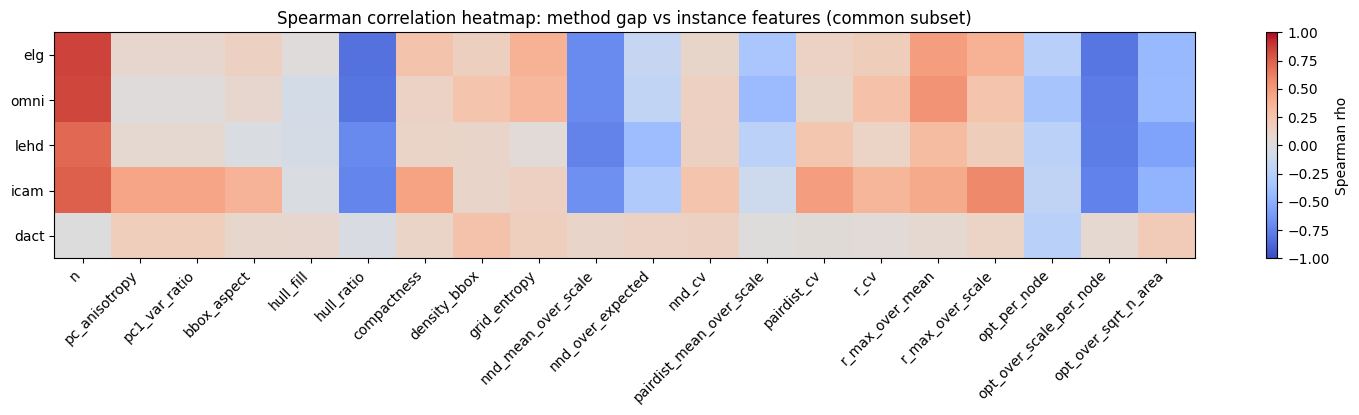


Instances with highest difficulty (avg gap across methods) [top 15]


instance,n,avg_gap,best_gap,std_gap,range_gap
u1060,1060,18.14389416287272,8.315400010709784,9.799396249605994,27.132670989290215
rl1889,1889,18.124705830823665,7.481159331008169,9.435890956688686,25.54881198347108
rl1304,1304,17.42256568495659,5.796818911396806,10.267551929222197,26.525635088603195
fl1577,1577,16.957559857782368,8.669630994651456,7.942779395603536,20.320295743628904
vm1748,1748,16.441903504809897,8.383978060114817,6.7898024457123265,18.58761062052079
pcb1173,1173,15.750366390845812,5.308330872530398,7.117156429076105,19.441276980946377
d1291,1291,15.643023832719825,7.641212771402128,8.459738776220984,19.428959075608756
fl1400,1400,15.492028101247087,6.106351666915089,9.321565502995513,26.799695333084912
rl1323,1323,14.305174248519057,4.520094448906176,8.410793523661708,21.22484261599784
vm1084,1084,14.153111709372874,5.06115960500968,6.38688768249339,18.325677394990322



Instances with highest selection opportunity (gap std across methods) [top 15]


instance,n,avg_gap,best_gap,std_gap,range_gap
pr76,76,8.954851689758593,0.11229125639105053,16.474685300812258,41.773265743608945
lin105,105,9.741169938883097,0.02779122331177941,15.969383665453732,41.53977277668822
a280,280,10.855368803101971,1.3506785575804425,13.369628975523867,36.06692544241955
gil262,262,8.45812625618166,0.6688730025231182,13.316780678655006,34.36056399747688
eil101,101,8.48014616788553,2.07572337042925,12.29694872644152,30.99263862957075
kroB100,100,7.431414202023392,-0.008697890790843044,12.172245711350204,31.70103289079084
u159,159,6.697497634600758,0.007240731939162082,11.705701431778891,30.083063268060837
eil76,76,7.95878806542751,1.1838289962825321,11.589885791090875,29.857063003717467
p654,654,13.226641608780994,3.88366480962965,10.7968740489746,29.93269019037035
kroC100,100,5.895457169280441,0.11930165309170793,10.503507433603268,26.763921346908294



Feature correlations with difficulty/opportunity (common subset)


feature,"spearman(feature,avg_gap)","spearman(feature,std_gap)","spearman(feature,range_gap)","pearson(feature,avg_gap)","pearson(feature,std_gap)"
hull_ratio,-0.7991591423185177,0.2346735065373009,0.14992662333143617,-0.6909788851987924,0.17908672607728796
n,0.7899681104862452,-0.2758274454095644,-0.18812669905116172,0.8869367101420391,-0.18396193568189767
opt_over_scale_per_node,-0.7311475409836066,0.33670015864621894,0.2565309360126917,-0.6933110389563905,0.3362240028536705
nnd_mean_over_scale,-0.6417239555790587,0.36530936012691695,0.2892120571126388,-0.5966174144474441,0.33999795040934455
r_max_over_mean,0.5343204653622422,-0.06409307244843998,-0.029613960867265997,0.2576490961599485,-0.15485386942637647
r_max_over_scale,0.40460074034902166,-0.0769962982548916,0.034003172924378634,0.31594229556296655,-0.035234140951203925
opt_over_sqrt_n_area,-0.36832363828662085,0.344632469592808,0.30428344791115813,-0.44098544981266985,0.32222030391957196
pairdist_mean_over_scale,-0.33950290851401377,0.06520359598096245,0.0718667371760973,-0.24597570112110698,0.11182286022153659
grid_entropy,0.31903754627181385,0.12702273929138022,0.15954521417239556,0.16670702763298675,0.2168659696825191
r_cv,0.2965097831835008,-0.03976731887890005,-0.009994711792702273,0.11831747399472281,-0.009439320060666152


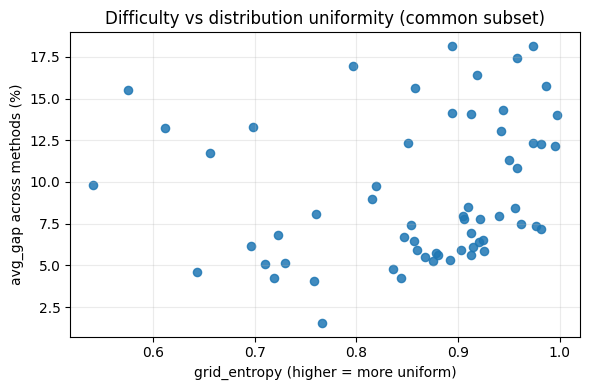

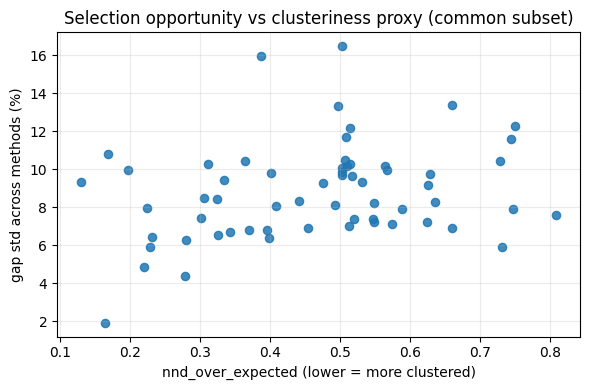


Observable feature distribution summary (common subset)


feature,count,min,p25,median,p75,max,mean,std
bbox_aspect,61,1.0,1.125,1.4511524635229436,1.9893832153690596,2.9874720357941835,1.5797495600660565,0.49526148385664126
compactness,61,1.0948331894162453,1.216194607978593,1.2719895607380591,1.359384015455508,1.7835408922172513,1.2974146098148693,0.12677966752219796
density_bbox,61,3.4013605442176873e-07,7.203817310767681e-06,2.5852542526462986e-05,0.00027209862076785316,0.020997920997921,0.0016171196922426785,0.004061310939941169
grid_entropy,61,0.5409871856812721,0.8155990667597959,0.8936707656908133,0.9400441637875058,0.9971954000602852,0.8584848969451194,0.1098090937295822
hull_fill,61,0.5153664984302492,0.9194899478778853,0.941915056228846,0.9797988264359634,1.0,0.9176411399052753,0.10061180552237918
hull_ratio,61,0.005,0.016786570743405275,0.03816793893129771,0.085,0.1568627450980392,0.055064712014474056,0.04559320829232386
n,61,51.0,124.0,225.0,657.0,1889.0,483.1311475409836,499.95089842214435
nnd_cv,61,0.0,0.40956310131719725,0.5443369472383142,0.6937867788214432,2.72197222071738,0.6590988781139026,0.4995731773148427
nnd_mean_over_scale,61,0.003450226474159316,0.01441696740780705,0.029641990989278326,0.04629168625293558,0.11320045459030109,0.03282874941939338,0.022364150952173346
nnd_over_expected,61,0.12909565373081214,0.33345835608444313,0.5017482466475699,0.5636168581759192,0.8084129445351502,0.4647641618810494,0.16342216801240414


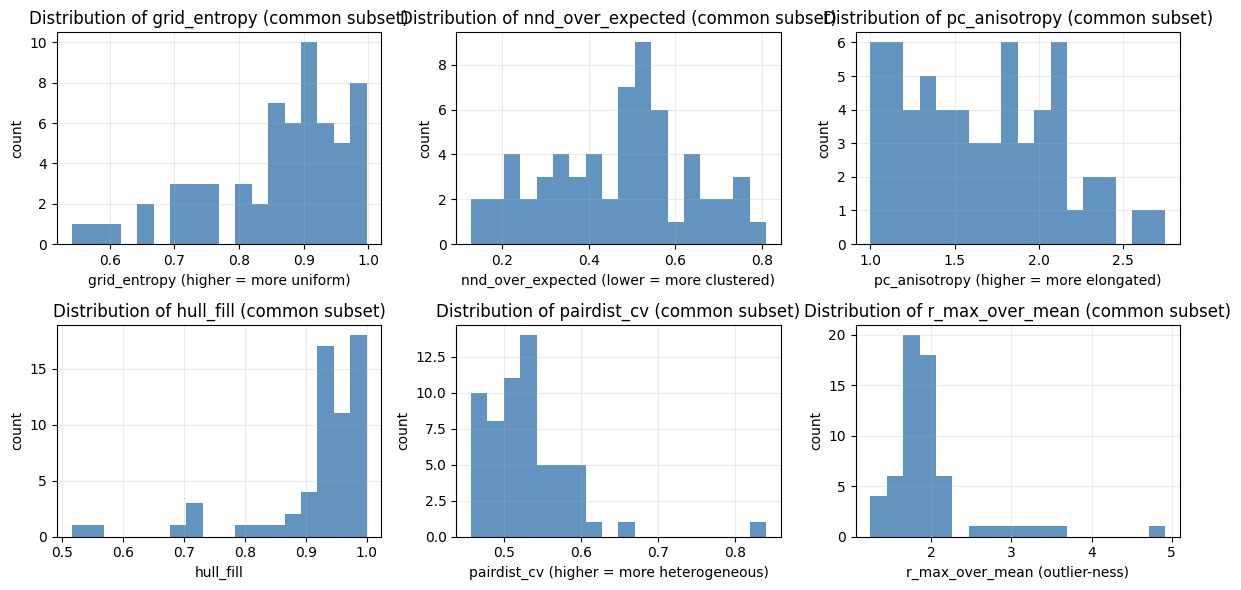

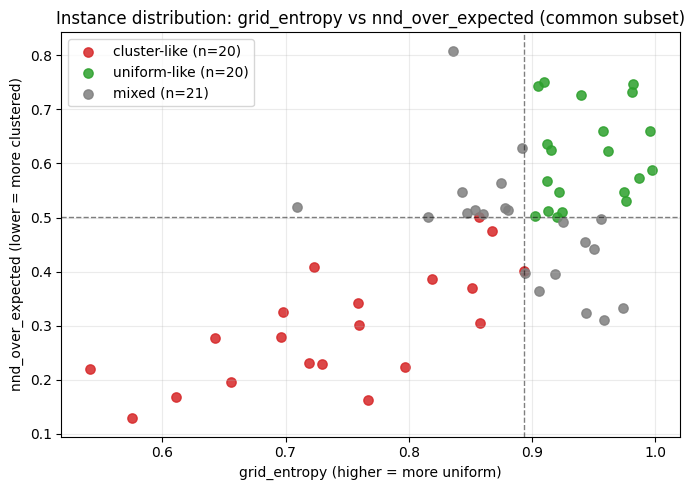


Examples: most cluster-like (low grid_entropy & low nnd_over_expected) [top 10]


instance,n,grid_entropy,nnd_over_expected,nnd_cv,pairdist_cv,pc_anisotropy
d198,198,0.5409871856812721,0.22010437191281407,1.8329255555891635,0.8406630163780671,2.748735315036116
fl1400,1400,0.5752109247445185,0.12909565373081214,2.72197222071738,0.5897203741718657,1.870878974346069
p654,654,0.6112437581110565,0.1681674884365163,2.0570714540517305,0.5879537686705093,1.8675632081098723
pr107,107,0.6429672978636906,0.2772799258824377,0.03970228423352634,0.5680535206956919,1.788777574116497
fl417,417,0.6555472494647504,0.19593336227418892,1.760335222307584,0.5800106041175432,1.8863219611453679
pr264,264,0.6964135473608948,0.27978753840157533,0.5110298418764714,0.6040494099398753,1.877728819491523
d493,493,0.6982002300967574,0.32480968761596757,1.8303791573571153,0.6523828047507731,1.6030414132345907
berlin52,52,0.7095585345956248,0.5190242322980056,0.7800303968033011,0.5985809326391845,1.513734505055526
pr226,226,0.7191750286343346,0.23105660967477343,1.4253083729864446,0.49431072426567363,1.2668099228004155
bier127,127,0.7227613446734567,0.4085876769911515,1.257313957164156,0.6242739552236791,1.1363976324547818



Examples: most uniform-like (high grid_entropy & high nnd_over_expected) [top 10]


instance,n,grid_entropy,nnd_over_expected,nnd_cv,pairdist_cv,pc_anisotropy
rat783,783,0.9971954000602852,0.5877575524301051,0.40956310131719725,0.5442019273419318,2.1393833775673605
rat575,575,0.9953936912280827,0.6594378379877694,0.3245189388921613,0.5435895275402601,2.170627858412609
pcb1173,1173,0.986871855342103,0.573990954542963,0.32776273731828853,0.5020212344930557,1.4870953085433893
u1432,1432,0.9820653954442741,0.7467821164542117,0.08182077667298224,0.48836194747135137,1.2845727240446498
rat195,195,0.9812899469251415,0.7314448067842582,0.1878180212075936,0.5513505676845251,2.2907991054743406
rd400,400,0.9763932490835779,0.530862002574674,0.533647823506175,0.47199672064817627,1.0248297829397
u724,724,0.9741736841484221,0.5473522271662952,0.5022564097278944,0.519415199922568,1.8544702724664566
rl1889,1889,0.9736916492147694,0.33345835608444313,0.6607296281449244,0.5098308635388764,1.6808384446374172
pcb442,442,0.9615747866457725,0.6231871728263815,0.2392247361017976,0.4754557605275119,1.0605184378459824
rl1304,1304,0.9581924057395469,0.31144426170465705,0.6308803630211165,0.5110464433582574,1.5330618013605255



Winner breakdown by instance distribution group (common subset)


group,count,dact_wins,dact_win_ratio(%),elg_wins,elg_win_ratio(%),icam_wins,icam_win_ratio(%),lehd_wins,lehd_win_ratio(%),omni_wins,omni_win_ratio(%)
cluster-like,20,0,0.0,6,30.0,1,5.0,11,55.0,2,10.0
mixed,21,0,0.0,3,14.285714285714286,3,14.285714285714286,18,85.71428571428571,1,4.761904761904762
uniform-like,20,0,0.0,0,0.0,2,10.0,18,90.0,0,0.0


In [21]:
# 10.3.2 数学分析：gap 与特征的相关性（Pearson + Spearman）

feat_by_inst = {r['instance']: r for r in feature_rows}

# 分成两类特征：
# - OBSERVABLE：只依赖实例坐标/规模，推理时也能算（更贴近 solver selection 的实际可用信息）
# - OPT_DEPENDENT：依赖 TSPLIB optimal（推理时不可得，仅用于事后解释/对照）
FEATURE_KEYS_OBSERVABLE = [
    'n',
    'pc_anisotropy',
    'pc1_var_ratio',
    'bbox_aspect',
    'hull_fill',
    'hull_ratio',
    'compactness',
    'density_bbox',
    'grid_entropy',
    'nnd_mean_over_scale',
    'nnd_over_expected',
    'nnd_cv',
    'pairdist_mean_over_scale',
    'pairdist_cv',
    'r_cv',
    'r_max_over_mean',
    'r_max_over_scale',
]

FEATURE_KEYS_OPT_DEPENDENT = [
    'opt_per_node',
    'opt_over_scale_per_node',
    'opt_over_sqrt_n_area',
]

FEATURE_KEYS = FEATURE_KEYS_OBSERVABLE + FEATURE_KEYS_OPT_DEPENDENT

# 供后续 cell 使用：偏好画像 & PCA 默认只用 observable 特征（更贴近可部署的 selection）。
FEATURE_KEYS_PROFILE = FEATURE_KEYS_OBSERVABLE
FEATURE_KEYS_PCA = FEATURE_KEYS_OBSERVABLE


def pearson(x, y):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 3:
        return None
    x = x[mask]
    y = y[mask]
    x = x - x.mean()
    y = y - y.mean()
    denom = np.sqrt(np.sum(x * x) * np.sum(y * y))
    if denom == 0:
        return None
    return float(np.sum(x * y) / denom)



def rankdata(a: np.ndarray) -> np.ndarray:
    # 简单 rankdata（平均秩），用于 Spearman
    a = np.asarray(a, dtype=np.float64)
    order = np.argsort(a)
    ranks = np.empty_like(order, dtype=np.float64)
    ranks[order] = np.arange(len(a), dtype=np.float64)

    # 平均秩处理 ties
    sorted_a = a[order]
    i = 0
    while i < len(a):
        j = i
        while j + 1 < len(a) and sorted_a[j + 1] == sorted_a[i]:
            j += 1
        if j > i:
            avg = 0.5 * (i + j)
            ranks[order[i : j + 1]] = avg
        i = j + 1
    return ranks



def spearman(x, y):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 3:
        return None
    rx = rankdata(x[mask])
    ry = rankdata(y[mask])
    return pearson(rx, ry)


corr_rows = []
for method in methods:
    k = method_best_run[method]
    # method 在 common 上的 gap
    gaps = {inst: method_gap[method].get(inst) for inst in common}

    row = {'method': method, 'variant': k[1]}
    for fk in FEATURE_KEYS:
        xs = []
        ys = []
        for inst, g in gaps.items():
            if g is None:
                continue
            f = feat_by_inst.get(inst)
            if not f:
                continue
            xs.append(f.get(fk))
            ys.append(g)
        row[f'pearson(gap,{fk})'] = pearson(xs, ys)
        row[f'spearman(gap,{fk})'] = spearman(xs, ys)

    corr_rows.append(row)


def max_abs_corr(row, prefix: str):
    vals = [v for k, v in row.items() if k.startswith(prefix) and v is not None]
    return max((abs(v) for v in vals), default=-1)

corr_rows.sort(key=lambda r: (-max_abs_corr(r, 'spearman('), -max_abs_corr(r, 'pearson('), r['method']))

show_cols = ['method', 'variant']
for fk in FEATURE_KEYS:
    show_cols.append(f'spearman(gap,{fk})')
for fk in FEATURE_KEYS:
    show_cols.append(f'pearson(gap,{fk})')

display_table(
    corr_rows,
    show_cols,
    max_rows=50,
    title='方法 gap 与实例特征的相关系数（Spearman 更看“单调关系”，Pearson 更看“线性关系”）',
)

# --- 额外 1：把 Spearman 相关系数画成热力图（更直观）
methods_order = [r['method'] for r in corr_rows]
spearman_mat = np.full((len(methods_order), len(FEATURE_KEYS)), np.nan, dtype=np.float64)
for i, r in enumerate(corr_rows):
    for j, fk in enumerate(FEATURE_KEYS):
        v = r.get(f'spearman(gap,{fk})')
        spearman_mat[i, j] = float(v) if v is not None else np.nan

plt.figure(figsize=(max(10, 0.6 * len(FEATURE_KEYS) + 3), max(2.8, 0.55 * len(methods_order) + 1.5)))
im = plt.imshow(spearman_mat, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, label='Spearman rho')
plt.xticks(range(len(FEATURE_KEYS)), FEATURE_KEYS, rotation=45, ha='right')
plt.yticks(range(len(methods_order)), methods_order)
plt.title('Spearman correlation heatmap: method gap vs instance features (common subset)')
plt.tight_layout()
plt.show()

# --- 额外 2：实例“难度/可选择性”指标（与 solver selection 更相关）
# difficulty: 多方法平均 gap（越大越难）
# opportunity: 多方法 gap 的离散程度（std/range）（越大越“值得做选择”）
inst_metrics = []
for inst in sorted(common):
    g_list = []
    ok = True
    for m in methods:
        v = method_gap[m].get(inst)
        if v is None:
            ok = False
            break
        g_list.append(float(v))
    if not ok:
        continue
    g = np.asarray(g_list, dtype=np.float64)
    inst_metrics.append({
        'instance': inst,
        'n': meta.get(inst, {}).get('n'),
        'avg_gap': float(g.mean()),
        'best_gap': float(g.min()),
        'std_gap': float(g.std()),
        'range_gap': float(g.max() - g.min()),
    })

display_table(
    sorted(inst_metrics, key=lambda r: -r['avg_gap'])[:15],
    ['instance', 'n', 'avg_gap', 'best_gap', 'std_gap', 'range_gap'],
    max_rows=15,
    title='Instances with highest difficulty (avg gap across methods) [top 15]',
)

display_table(
    sorted(inst_metrics, key=lambda r: -r['std_gap'])[:15],
    ['instance', 'n', 'avg_gap', 'best_gap', 'std_gap', 'range_gap'],
    max_rows=15,
    title='Instances with highest selection opportunity (gap std across methods) [top 15]',
)

# 与特征的相关性：哪个特征更能解释“难度/可选择性”
metric_corr = []
for fk in FEATURE_KEYS:
    xs = []
    y_avg = []
    y_std = []
    y_rng = []
    for r in inst_metrics:
        inst = r['instance']
        f = feat_by_inst.get(inst)
        if not f:
            continue
        x = f.get(fk)
        if x is None or not np.isfinite(x):
            continue
        xs.append(float(x))
        y_avg.append(r['avg_gap'])
        y_std.append(r['std_gap'])
        y_rng.append(r['range_gap'])

    metric_corr.append({
        'feature': fk,
        'spearman(feature,avg_gap)': spearman(xs, y_avg),
        'spearman(feature,std_gap)': spearman(xs, y_std),
        'spearman(feature,range_gap)': spearman(xs, y_rng),
        'pearson(feature,avg_gap)': pearson(xs, y_avg),
        'pearson(feature,std_gap)': pearson(xs, y_std),
    })

metric_corr.sort(key=lambda r: (-(abs(r['spearman(feature,avg_gap)']) if r['spearman(feature,avg_gap)'] is not None else -1),
                                -(abs(r['spearman(feature,std_gap)']) if r['spearman(feature,std_gap)'] is not None else -1),
                                r['feature']))

display_table(
    metric_corr,
    ['feature', 'spearman(feature,avg_gap)', 'spearman(feature,std_gap)', 'spearman(feature,range_gap)', 'pearson(feature,avg_gap)', 'pearson(feature,std_gap)'],
    max_rows=50,
    title='Feature correlations with difficulty/opportunity (common subset)',
)

# 两个直观散点图（注意：这里只看相关性，不代表因果）
def scatter_feature_metric(feature_key: str, metric_key: str, title: str, xlabel: str, ylabel: str):
    xs = []
    ys = []
    for r in inst_metrics:
        inst = r['instance']
        f = feat_by_inst.get(inst)
        if not f:
            continue
        x = f.get(feature_key)
        y = r.get(metric_key)
        if x is None or y is None:
            continue
        if not np.isfinite(float(x)) or not np.isfinite(float(y)):
            continue
        xs.append(float(x))
        ys.append(float(y))
    if not xs:
        return
    plt.figure(figsize=(6, 4))
    plt.scatter(xs, ys, s=35, alpha=0.85)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

scatter_feature_metric(
    'grid_entropy',
    'avg_gap',
    'Difficulty vs distribution uniformity (common subset)',
    'grid_entropy (higher = more uniform)',
    'avg_gap across methods (%)',
)

scatter_feature_metric(
    'nnd_over_expected',
    'std_gap',
    'Selection opportunity vs clusteriness proxy (common subset)',
    'nnd_over_expected (lower = more clustered)',
    'gap std across methods (%)',
)

# --- 额外 3：实例“分布特征”本身的分析（新手很建议先看这个）
# 目标：回答“这 61 个 TSPLIB 实例在几何/分布上大概长什么样？”
# 你会看到：
# 1) 每个特征的分布统计（min/median/max 等）
# 2) 多个关键特征的直方图（分布是否集中/离散/多峰）
# 3) 一个二维散点：grid_entropy vs nnd_over_expected，用来直观看“均匀 vs 聚团”

def feature_values(feature_key: str):
    insts = []
    vals = []
    for inst in sorted(common):
        f = feat_by_inst.get(inst)
        if not f:
            continue
        v = f.get(feature_key)
        if v is None:
            continue
        v = float(v)
        if not np.isfinite(v):
            continue
        insts.append(inst)
        vals.append(v)
    return np.asarray(vals, dtype=np.float64), insts


# 3.1 特征分布摘要表（可快速判断：这个特征在数据里有没有变化）
summary_rows = []
for fk in FEATURE_KEYS_OBSERVABLE:
    arr, _ = feature_values(fk)
    if arr.size < 3:
        continue
    summary_rows.append({
        'feature': fk,
        'count': int(arr.size),
        'min': float(arr.min()),
        'p25': float(np.percentile(arr, 25)),
        'median': float(np.median(arr)),
        'p75': float(np.percentile(arr, 75)),
        'max': float(arr.max()),
        'mean': float(arr.mean()),
        'std': float(arr.std()),
    })

summary_rows.sort(key=lambda r: r['feature'])
display_table(
    summary_rows,
    ['feature', 'count', 'min', 'p25', 'median', 'p75', 'max', 'mean', 'std'],
    max_rows=200,
    title='Observable feature distribution summary (common subset)',
)


# 3.2 直方图：挑 6 个最直观的“分布/形状”特征
HIST_FEATURES = [
    ('grid_entropy', 'grid_entropy (higher = more uniform)'),
    ('nnd_over_expected', 'nnd_over_expected (lower = more clustered)'),
    ('pc_anisotropy', 'pc_anisotropy (higher = more elongated)'),
    ('hull_fill', 'hull_fill'),
    ('pairdist_cv', 'pairdist_cv (higher = more heterogeneous)'),
    ('r_max_over_mean', 'r_max_over_mean (outlier-ness)'),
]

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.ravel()
for ax, (fk, xlabel) in zip(axes, HIST_FEATURES):
    arr, _ = feature_values(fk)
    if arr.size == 0:
        ax.set_visible(False)
        continue
    ax.hist(arr, bins=18, color='steelblue', alpha=0.85)
    ax.set_title(f'Distribution of {fk} (common subset)')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('count')
    ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


# 3.3 二维散点：均匀 vs 聚团
# - grid_entropy 高：更均匀
# - nnd_over_expected 低：更聚团
pts = []
for inst in sorted(common):
    f = feat_by_inst.get(inst)
    if not f:
        continue
    ge = f.get('grid_entropy')
    nnd = f.get('nnd_over_expected')
    if ge is None or nnd is None:
        continue
    ge = float(ge)
    nnd = float(nnd)
    if not (np.isfinite(ge) and np.isfinite(nnd)):
        continue
    pts.append((inst, ge, nnd))

if pts:
    ge_arr = np.asarray([x[1] for x in pts], dtype=np.float64)
    nnd_arr = np.asarray([x[2] for x in pts], dtype=np.float64)
    ge_med = float(np.median(ge_arr))
    nnd_med = float(np.median(nnd_arr))

    groups = {
        'cluster-like': [],
        'uniform-like': [],
        'mixed': [],
    }
    for inst, ge, nnd in pts:
        if ge <= ge_med and nnd <= nnd_med:
            groups['cluster-like'].append((inst, ge, nnd))
        elif ge >= ge_med and nnd >= nnd_med:
            groups['uniform-like'].append((inst, ge, nnd))
        else:
            groups['mixed'].append((inst, ge, nnd))

    color = {
        'cluster-like': '#d62728',
        'uniform-like': '#2ca02c',
        'mixed': '#7f7f7f',
    }

    plt.figure(figsize=(7, 5))
    for gname in ['cluster-like', 'uniform-like', 'mixed']:
        xs = [x[1] for x in groups[gname]]
        ys = [x[2] for x in groups[gname]]
        if xs:
            plt.scatter(xs, ys, s=45, alpha=0.85, label=f'{gname} (n={len(xs)})', color=color[gname])
    plt.axvline(ge_med, linestyle='--', color='black', alpha=0.5, linewidth=1)
    plt.axhline(nnd_med, linestyle='--', color='black', alpha=0.5, linewidth=1)
    plt.xlabel('grid_entropy (higher = more uniform)')
    plt.ylabel('nnd_over_expected (lower = more clustered)')
    plt.title('Instance distribution: grid_entropy vs nnd_over_expected (common subset)')
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 列几个极端例子，方便你回去看具体实例
    def feat_row(inst: str):
        f = feat_by_inst.get(inst, {})
        return {
            'instance': inst,
            'n': meta.get(inst, {}).get('n'),
            'grid_entropy': f.get('grid_entropy'),
            'nnd_over_expected': f.get('nnd_over_expected'),
            'nnd_cv': f.get('nnd_cv'),
            'pairdist_cv': f.get('pairdist_cv'),
            'pc_anisotropy': f.get('pc_anisotropy'),
        }

    most_clustered = [x[0] for x in sorted(pts, key=lambda t: (t[1], t[2]))[:10]]
    most_uniform = [x[0] for x in sorted(pts, key=lambda t: (-t[1], -t[2]))[:10]]

    display_table(
        [feat_row(i) for i in most_clustered],
        ['instance', 'n', 'grid_entropy', 'nnd_over_expected', 'nnd_cv', 'pairdist_cv', 'pc_anisotropy'],
        max_rows=20,
        title='Examples: most cluster-like (low grid_entropy & low nnd_over_expected) [top 10]',
    )

    display_table(
        [feat_row(i) for i in most_uniform],
        ['instance', 'n', 'grid_entropy', 'nnd_over_expected', 'nnd_cv', 'pairdist_cv', 'pc_anisotropy'],
        max_rows=20,
        title='Examples: most uniform-like (high grid_entropy & high nnd_over_expected) [top 10]',
    )

    # 3.4 group-wise 的 winner 统计：方法在不同“分布类型”实例上的胜率
    EPS_LOCAL = globals().get('EPS', 1e-9)
    inst_winners_local = {}
    for inst in sorted(common):
        vals = []
        ok = True
        for m in methods:
            v = method_gap[m].get(inst)
            if v is None:
                ok = False
                break
            vals.append((m, float(v)))
        if not ok:
            continue
        best = min(v for _, v in vals)
        winners = [m for m, v in vals if abs(v - best) <= EPS_LOCAL]
        inst_winners_local[inst] = winners

    grp_rows = []
    for gname, items in groups.items():
        insts = [x[0] for x in items]
        row = {'group': gname, 'count': len(insts)}
        for m in methods:
            w = sum(1 for inst in insts if m in inst_winners_local.get(inst, []))
            row[f'{m}_wins'] = w
            row[f'{m}_win_ratio(%)'] = (100.0 * w / len(insts)) if insts else None
        grp_rows.append(row)

    # 为了好读，按 group 排序输出
    grp_rows.sort(key=lambda r: r['group'])
    show = ['group', 'count']
    for m in methods:
        show += [f'{m}_wins', f'{m}_win_ratio(%)']
    display_table(
        grp_rows,
        show,
        max_rows=50,
        title='Winner breakdown by instance distribution group (common subset)',
    )


In [22]:
# 10.3.3 偏好性：winner 的特征偏移 + 置换检验（更偏数学一点）

# 定义每个 instance 的赢家方法（基于 method_gap；并列 winner 也算赢）

EPS_WIN = globals().get('EPS', 1e-9)

inst_winner = {}
for inst in common:
    vals = []
    for method in methods:
        v = method_gap[method].get(inst)
        if v is None:
            break
        vals.append((method, v))
    if len(vals) != len(methods):
        continue
    best = min(v for _, v in vals)
    winners = [m for m, v in vals if abs(v - best) <= EPS_WIN]
    inst_winner[inst] = winners


def permutation_pvalue(all_vals: np.ndarray, mask: np.ndarray, n_perm: int = 5000, seed: int = 0) -> float | None:
    # two-sided permutation test for difference in means
    all_vals = np.asarray(all_vals, dtype=np.float64)
    mask = np.asarray(mask, dtype=bool)
    if mask.sum() < 3 or (~mask).sum() < 3:
        return None
    rng = np.random.default_rng(seed)

    obs = all_vals[mask].mean() - all_vals[~mask].mean()
    cnt = 0
    for _ in range(n_perm):
        perm = rng.permutation(mask)
        diff = all_vals[perm].mean() - all_vals[~perm].mean()
        if abs(diff) >= abs(obs) - 1e-12:
            cnt += 1
    return (cnt + 1) / (n_perm + 1)


def effect_size(all_vals: np.ndarray, mask: np.ndarray) -> float | None:
    # Cohen's d using pooled std (here simplified using overall std)
    all_vals = np.asarray(all_vals, dtype=np.float64)
    mask = np.asarray(mask, dtype=bool)
    if mask.sum() < 3 or (~mask).sum() < 3:
        return None
    sd = all_vals.std()
    if sd == 0:
        return None
    return float((all_vals[mask].mean() - all_vals[~mask].mean()) / sd)


# 只用“推理时可得”的 observable 特征做偏好画像（避免把 optimal 引入分析导致误解）
FEATURE_KEYS_USED = globals().get('FEATURE_KEYS_PROFILE', FEATURE_KEYS)

profile = []
for method in methods:
    win_insts = [inst for inst, winners in inst_winner.items() if method in winners]

    row = {
        'method': method,
        'wins': len(win_insts),
        'win_ratio(%)': 100.0 * len(win_insts) / len(common),
    }

    for fk in FEATURE_KEYS_USED:
        xs = []
        ys = []
        insts = []
        for inst in common:
            f = feat_by_inst.get(inst)
            if not f:
                continue
            v = f.get(fk)
            if v is None or not np.isfinite(v):
                continue
            insts.append(inst)
            xs.append(float(v))
            ys.append(inst in win_insts)

        if len(xs) < 10:
            row[f'effect({fk})'] = None
            row[f'p({fk})'] = None
            continue

        x = np.asarray(xs, dtype=np.float64)
        m = np.asarray(ys, dtype=bool)
        row[f'effect({fk})'] = effect_size(x, m)
        row[f'p({fk})'] = permutation_pvalue(x, m, n_perm=3000, seed=0)

    profile.append(row)

profile.sort(key=lambda r: (-r['wins'], r['method']))

cols = ['method', 'wins', 'win_ratio(%)']
for fk in FEATURE_KEYS_USED:
    cols.append(f'effect({fk})')
for fk in FEATURE_KEYS_USED:
    cols.append(f'p({fk})')

display_table(
    profile,
    cols,
    max_rows=50,
    title='winner 偏好画像：特征偏移(effect size) + 置换检验 p-value（p 越小，越可能有“偏好性差异”）',
)



winner 偏好画像：特征偏移(effect size) + 置换检验 p-value（p 越小，越可能有“偏好性差异”）


method,wins,win_ratio(%),effect(n),effect(pc_anisotropy),effect(pc1_var_ratio),effect(bbox_aspect),effect(hull_fill),effect(hull_ratio),effect(compactness),effect(density_bbox),effect(grid_entropy),effect(nnd_mean_over_scale),effect(nnd_over_expected),effect(nnd_cv),effect(pairdist_mean_over_scale),effect(pairdist_cv),effect(r_cv),effect(r_max_over_mean),effect(r_max_over_scale),p(n),p(pc_anisotropy),p(pc1_var_ratio),p(bbox_aspect),p(hull_fill),p(hull_ratio),p(compactness),p(density_bbox),p(grid_entropy),p(nnd_mean_over_scale),p(nnd_over_expected),p(nnd_cv),p(pairdist_mean_over_scale),p(pairdist_cv),p(r_cv),p(r_max_over_mean),p(r_max_over_scale)
lehd,47,77.04918032786885,0.417369254455088,0.17155156811353858,0.22754575997441678,0.7323090999921195,0.25276178433906665,-0.1961929555439945,0.30148073943113973,-0.04605637227086668,1.1084139331501608,0.09140320118574936,0.7370154159367653,-0.33269643439380925,-0.17048200267906252,-0.5778377615277527,0.16979919982435498,0.28488199437109213,0.7034090266443844,0.17727424191936023,0.5784738420526491,0.457514161946018,0.014995001666111295,0.42852382539153616,0.5314895034988337,0.33088970343218926,0.8833722092635788,0.0003332222592469177,0.7747417527490836,0.013662112629123625,0.3018993668777074,0.6041319560146617,0.055314895034988334,0.5891369543485505,0.3915361546151283,0.01899366877707431
elg,9,14.754098360655737,-0.2795274504777448,-0.3004049780032282,-0.22979223062792317,-0.7077399702393299,-0.06767449473144893,0.5163454594381817,-0.5759086935106844,-0.19175976258649507,-1.061727966688998,0.03128337877707505,-0.7786590078145598,0.46629702623160324,0.31060364879237295,0.10378089582101734,-0.02450308764391294,-0.4025713002124229,-0.7117451787525901,0.4538487170943019,0.41319560146617795,0.530156614461846,0.051649450183272244,0.85838053982006,0.1599466844385205,0.10296567810729756,0.7054315228257247,0.0026657780739753416,0.9306897700766411,0.026324558480506497,0.1922692435854715,0.41186271242919026,0.7827390869710097,0.9436854381872709,0.26391202932355884,0.04965011662779074
icam,6,9.836065573770492,-0.6454755089440339,-1.1009694416140114,-1.2999310352967945,-1.0771530051958322,0.24218555279775458,0.7261254929000204,-0.9033059704818741,1.2750336695178048,0.15783010651890772,1.0940560656666831,0.7181802784245949,-0.4702759080621132,-0.016149735868162828,-0.7409515442063095,-0.6815557231769395,-0.4123125212639054,-0.9344821505770865,0.137620793068977,0.012329223592135955,0.0023325558147284237,0.010329890036654448,0.6351216261246251,0.0923025658113962,0.03898700433188937,0.01166277907364212,0.7190936354548484,0.014661779406864379,0.10796401199600134,0.2725758080639787,0.9720093302232589,0.0789736754415195,0.11396201266244585,0.3122292569143619,0.0319893368877041
omni,3,4.918032786885246,-0.732347780932131,1.332004605469703,1.111102956966784,0.37160031619516826,-1.0604804417418072,0.35550315385779313,1.3765441412713477,-0.41534462073777395,-1.6313628155423827,-0.07286492826559944,-0.8216285539206669,0.307194274159579,0.14918005595801065,2.118690010631967,0.24681664030082523,0.24597216802217572,0.1784363337465748,0.1956014661779407,0.019326891036321226,0.051649450183272244,0.5351549483505498,0.07630789736754415,0.5814728423858714,0.025324891702765744,0.2772409196934355,0.006664445184938354,0.8997000999666778,0.16861046317894035,0.6291236254581806,0.8130623125624792,0.00866377874041986,0.5828057314228591,0.6997667444185272,0.749083638787071
dact,0,0.0,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None


instances used for PCA: 61 / 61


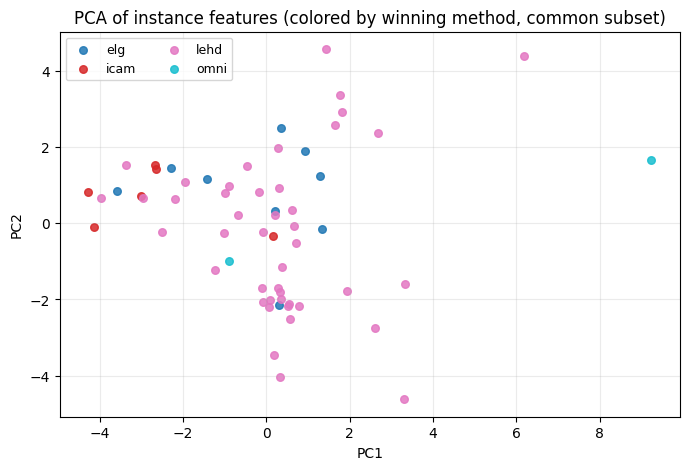


PCA loadings（用于解释 PC1/PC2 的含义）


feature,PC1_loading,PC2_loading
n,0.09951366929605414,0.12571417642499905
pc_anisotropy,0.28732679898296987,-0.353143632101827
pc1_var_ratio,0.28528314581428077,-0.33585637919882594
bbox_aspect,0.21084624286506282,-0.41529793858906544
hull_fill,-0.23767412596482881,-0.2892929597860063
hull_ratio,-0.1591657503499605,-0.13332392012500907
compactness,0.31311469482791093,-0.25701062273039726
density_bbox,-0.19753945002656653,-0.030627786609054256
grid_entropy,-0.18605525393119773,-0.20842448854007908
nnd_mean_over_scale,-0.2230094775482648,-0.1482805304892553


In [23]:
# 10.3.4 PCA 可视化：特征空间里赢家是否“可分/聚团”

# 只取所有特征都不缺失的实例用于 PCA
# 默认只用 observable 特征（更贴近“推理时可用的实例特征”）
FEATURE_KEYS_USED = globals().get('FEATURE_KEYS_PCA', FEATURE_KEYS)

inst_ok = []
X = []
labels = []

for inst in sorted(common):
    f = feat_by_inst.get(inst)
    if not f:
        continue
    vals = []
    ok = True
    for fk in FEATURE_KEYS_USED:
        v = f.get(fk)
        if v is None or not np.isfinite(v):
            ok = False
            break
        vals.append(float(v))
    if not ok:
        continue

    winners = inst_winner.get(inst, [])
    label = winners[0] if winners else 'unknown'

    inst_ok.append(inst)
    X.append(vals)
    labels.append(label)

X = np.asarray(X, dtype=np.float64)
print('instances used for PCA:', len(inst_ok), '/', len(common))

# 标准化
mu = X.mean(axis=0)
sd = X.std(axis=0)
sd[sd == 0] = 1.0
Z = (X - mu) / sd

# PCA via SVD
U, S, Vt = np.linalg.svd(Z, full_matrices=False)
PC = Z @ Vt.T[:, :2]

plt.figure(figsize=(8, 5))
uniq = sorted(set(labels))
colors = plt.cm.tab10(np.linspace(0, 1, max(len(uniq), 3)))
color_map = {lab: colors[i % len(colors)] for i, lab in enumerate(uniq)}

for lab in uniq:
    idxs = [i for i, x in enumerate(labels) if x == lab]
    pts = PC[idxs]
    plt.scatter(pts[:, 0], pts[:, 1], s=30, alpha=0.85, label=lab, color=color_map[lab])

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of instance features (colored by winning method, common subset)')
plt.grid(True, alpha=0.25)
plt.legend(ncol=2, fontsize=9)
plt.show()

# PCA loadings：解释 PC 轴
loading = []
for i, fk in enumerate(FEATURE_KEYS_USED):
    loading.append({
        'feature': fk,
        'PC1_loading': float(Vt.T[i, 0]),
        'PC2_loading': float(Vt.T[i, 1]),
    })

display_table(loading, ['feature', 'PC1_loading', 'PC2_loading'], max_rows=50, title='PCA loadings（用于解释 PC1/PC2 的含义）')


## 11. 按规模分组（n 分桶）看趋势

很多方法在 TSPLIB 上的表现强弱，与实例规模强相关。

这里把 n 做分桶：

- `<= 100`
- `101–200`
- `201–500`
- `501–1000`
- `1001–2000`
- `> 2000`

然后统计各 run 在共同子集上的每个桶的平均 gap。

### 新手怎么读下面的表/图？

下面紧跟着会输出 **一个表 + 一张折线图**。

**1) 表格（每行一个 run，每列一个桶）**

- 例如 `lehd/lehd_greedy_aug8` 在 `<=100` 桶的数值是：该 run 在所有 `n<=100` 的共同子集实例上的 **平均 gap**。
- 如果某一列是 `None`，通常表示：在共同子集里，这个 run 在该桶没有样本（例如 `>2000` 可能在 61 子集里缺失）。

**2) 折线图（更直观）**

- x 轴：规模桶（按 n 分段）。
- y 轴：该桶的 mean gap（越低越好）。
- 每条线：一个 run。

**3) 怎么从图里得到“有用结论”？**

- 如果某条线随着 n 增大明显上升：说明该方法随规模扩展更吃力（scaling 问题）。
- 如果两条线在不同桶发生“交叉”：说明方法的相对优劣**随规模变化**，这对 solver selection 很重要（可以按规模/特征做分流）。
- 注意：这里是按桶求平均，会掩盖桶内波动；所以建议结合下一节的散点图一起看。



共同子集(61)上：按 n 分桶的平均 gap(%)


run,<=100,101-200,201-500,501-1000,1001-2000,>2000
dact/dact_0,26.76748816666667,22.631475176470587,25.47961646153846,27.389029000000004,25.72118323076923,None
elg/elg_greedt,0.8537416666666667,1.879123529411765,4.754115384615385,8.590783333333333,11.170100000000001,None
icam/icam_greedy_aug8,1.5047583333333332,2.798441176470588,4.410715384615385,10.613966666666666,10.442815384615384,None
lehd/lehd_greedy_aug8,0.30553333333333327,1.834535294117647,1.7323769230769233,3.5675833333333333,6.459084615384616,None
lehd/lehd_greedy_no_aug,0.6143416666666667,3.1121529411764706,2.9418384615384614,5.26665,10.176846153846153,None
omni/omni_greedy,1.9531083333333334,1.8266235294117645,4.522684615384615,12.674616666666667,23.838630769230768,None


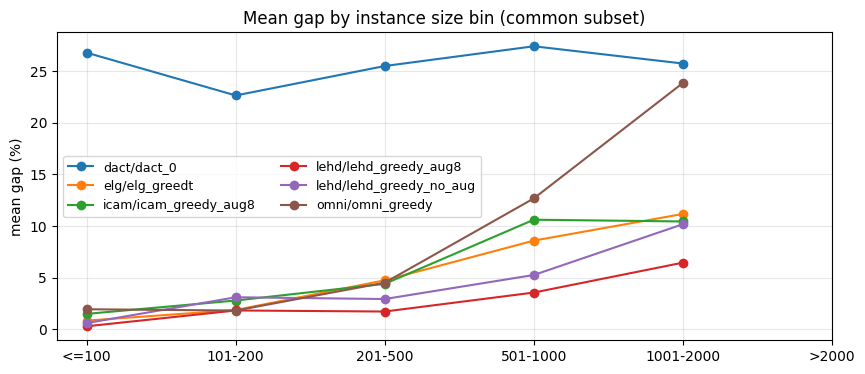

In [24]:
bins = [0, 100, 200, 500, 1000, 2000, 10**9]
bin_labels = ["<=100", "101-200", "201-500", "501-1000", "1001-2000", ">2000"]


def bucket(n: int | None) -> str | None:
    if n is None:
        return None
    for i in range(len(bins) - 1):
        if bins[i] < n <= bins[i + 1]:
            return bin_labels[i]
    return None


by_run_bucket = []
for k, rows in by_run.items():
    # 只在 common 上统计
    xs = defaultdict(list)
    for r in rows:
        inst = r.get("instance")
        if inst not in common:
            continue
        g = r.get("primary_gap")
        if g is None:
            continue
        b = bucket(r.get("n") or meta.get(inst, {}).get("n"))
        if b:
            xs[b].append(g)

    row = {"run": f"{k[0]}/{k[1]}"}
    for bl in bin_labels:
        row[bl] = float(np.mean(xs[bl])) if xs.get(bl) else None
    by_run_bucket.append(row)

display_table(by_run_bucket, ["run"] + bin_labels, max_rows=50, title="共同子集(61)上：按 n 分桶的平均 gap(%)")

# 简单画一张折线图
plt.figure(figsize=(10, 4))
x = np.arange(len(bin_labels))
for row in by_run_bucket:
    y = [row[b] if row[b] is not None else np.nan for b in bin_labels]
    plt.plot(x, y, marker='o', label=row['run'])
plt.xticks(x, bin_labels)
plt.ylabel('mean gap (%)')
plt.title('Mean gap by instance size bin (common subset)')
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=9)
plt.show()


## 12. 可视化：n vs gap（散点） + run 平均 gap（柱状）

散点图有助于直观看到：

- 小规模实例 gap 低但大规模变差
- 某些 run 在特定规模段突然崩掉（例如 n≈1000+）

### 新手怎么读下面两张图？

下面这个 code cell 会画两类图：

#### 1) Scatter：`n vs primary_gap`

- **一个点**≈“某个实例在某个 run 下的 gap”。
- **x 轴**是 `n`（用 log scale，因为 n 的跨度很大）。
- **y 轴**是 `primary_gap(%)`（越低越好）。
- **不同颜色/label**对应不同 run（例如 `lehd/lehd_greedy_aug8`）。

你可以这样读：

- 同一 n 区间里，某个 run 的点整体更低 → 说明它在该规模段更强。
- 如果某个 run 在大 n 时突然出现一串高点 → 说明它在大规模上不稳定或退化严重。
- 如果点的纵向散布很大 → 说明该 run 对“实例分布差异”很敏感（同样规模也可能差很多）。

#### 2) Bar：`mean primary_gap`（共同子集）

- 柱状图把每个 run 在共同子集(61)上的 gap 做平均，得到一个“总体强弱”排序。
- 它很适合作为 **quick summary**，但有一个新手常见坑：
  - 平均值会掩盖“某些实例特别差/特别好”的结构，所以一定要结合上面的散点图一起看。


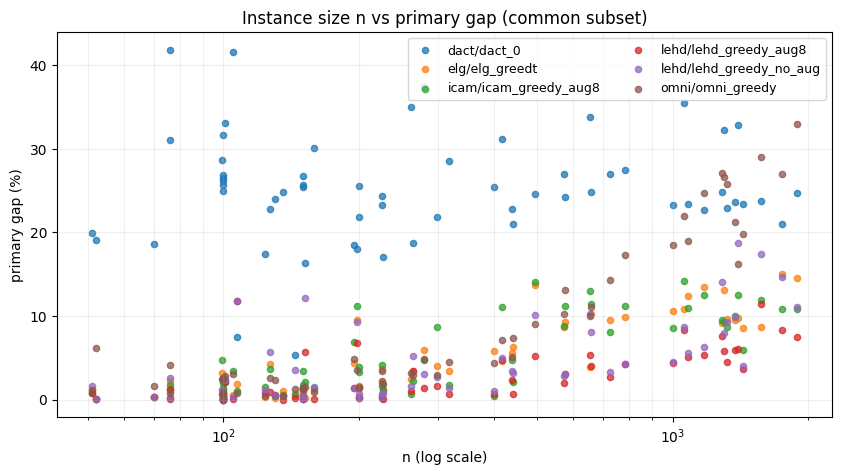

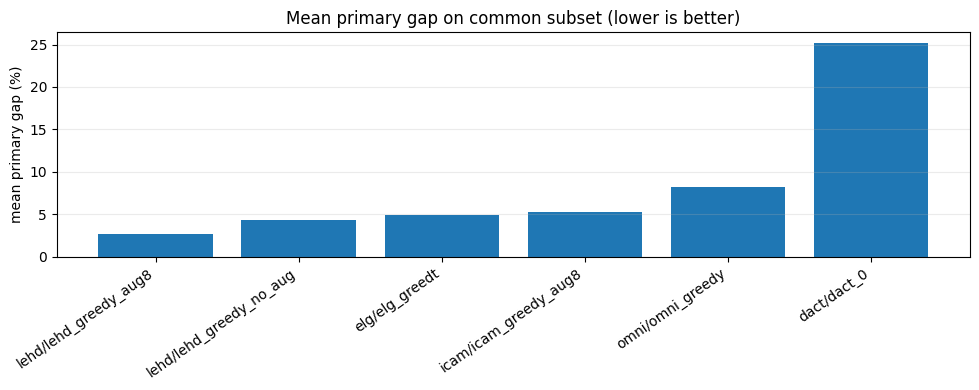

In [25]:
# 只画共同子集上的点，避免因覆盖不同误导
plt.figure(figsize=(10, 5))
for k, rows in by_run.items():
    xs = []
    ys = []
    for r in rows:
        if r.get("instance") not in common:
            continue
        n = r.get("n")
        g = r.get("primary_gap")
        if n is None or g is None:
            continue
        xs.append(n)
        ys.append(g)
    if xs:
        plt.scatter(xs, ys, s=20, alpha=0.75, label=f"{k[0]}/{k[1]}")

plt.xscale('log')
plt.xlabel('n (log scale)')
plt.ylabel('primary gap (%)')
plt.title('Instance size n vs primary gap (common subset)')
plt.grid(True, which='both', alpha=0.2)
plt.legend(ncol=2, fontsize=9)
plt.show()


# 柱状图：共同子集 mean gap
bars = []
for k, rows in by_run.items():
    mg = mean_gap_on(common, rows)
    bars.append((f"{k[0]}/{k[1]}", mg))
bars = [(n, v) for n, v in bars if v is not None]
bars.sort(key=lambda x: x[1])

plt.figure(figsize=(10, 4))
plt.bar([b[0] for b in bars], [b[1] for b in bars])
plt.xticks(rotation=35, ha='right')
plt.ylabel('mean primary gap (%)')
plt.title('Mean primary gap on common subset (lower is better)')
plt.grid(True, axis='y', alpha=0.25)
plt.tight_layout()
plt.show()


## 13. 同方法对比示例：LEHD no-aug vs aug8

你的目录里 LEHD 有两个设置：

- `lehd_greedy_no_aug.txt`：`aug_factor = 1`
- `lehd_greedy_aug8.txt`：`aug_factor = 8`

下面我们在 LEHD 自己的覆盖集合（70）上比较：

- 每个 instance 的 gap 差值：`delta = gap_aug8 - gap_no_aug`（负数代表提升）
- 统计提升/退化的数量
- 列出提升最大/退化最大的一些实例

### 新手怎么读输出？

这个对比的核心是：**同一个方法，只改一个开关（aug_factor）**，看看提升来自哪里。

你会看到 3 类输出：

#### 1) `improved / worsened / same`

- `improved`：`delta < 0`，表示 aug8 的 gap 更小（更好）。
- `worsened`：`delta > 0`，表示 aug8 更差。
- `same`：`delta ≈ 0`，增强基本没影响（通常是因为本来就已经很接近最优，或增强没有带来更好解）。

#### 2) Top 表：提升最大 / 退化最大

- “提升最大”那张表列的是 `delta` 最负的实例：这些实例最能体现 augmentation 的收益。
- “退化最大”那张表列的是 `delta` 最正的实例：通常需要回去检查是否是随机性/搜索失败/异常。

#### 3) 直方图：`delta gap` 的整体分布

- x 轴：`delta = gap_aug8 - gap_no_aug`。
- y 轴：出现次数。
- 如果大部分质量集中在 0 左侧：说明 augmentation 通常带来改进。
- 如果分布很宽：说明 augmentation 的收益非常依赖实例分布（有的提升很多，有的几乎不变）。


lehd_no: ('lehd', 'lehd_greedy_no_aug', 'eval_log')
lehd_aug: ('lehd', 'lehd_greedy_aug8', 'eval_log')
LEHD: improved=59, worsened=2, same=9, total=70

提升最大(最负)的 20 个实例


instance,n,gap_no_aug,gap_aug8,delta(aug8-no)
fl1400,1400,18.7642,6.1064,-12.657799999999998
fl3795,3795,20.4682,12.2864,-8.181799999999999
d1291,1291,14.1265,7.6412,-6.4853
pr152,152,12.1364,5.7477,-6.3887
vm1748,1748,14.7225,8.384,-6.3385
fl1577,1577,17.4684,11.4411,-6.0272999999999985
d493,493,10.1152,5.2487,-4.866499999999999
p654,654,10.2289,5.3841,-4.844799999999999
bier127,127,5.6343,0.8876,-4.7467
rl1323,1323,9.2624,4.5201,-4.742299999999999



退化最大(最正)的 20 个实例


instance,n,gap_no_aug,gap_aug8,delta(aug8-no)
kroB100,100,0.256,-0.0087,-0.2647
eil101,101,2.3092,2.0757,-0.23350000000000026
fl417,417,4.9308,4.7761,-0.15470000000000006
pr1002,1002,4.4524,4.3333,-0.11909999999999954
pr76,76,0.2192,0.1123,-0.10690000000000001
rat783,783,4.273,4.2066,-0.06639999999999979
ts225,225,0.279,0.224,-0.05500000000000002
kroC100,100,0.3247,0.3097,-0.015000000000000013
st70,70,0.3254,0.3125,-0.012900000000000023
berlin52,52,0.0314,0.0314,0.0


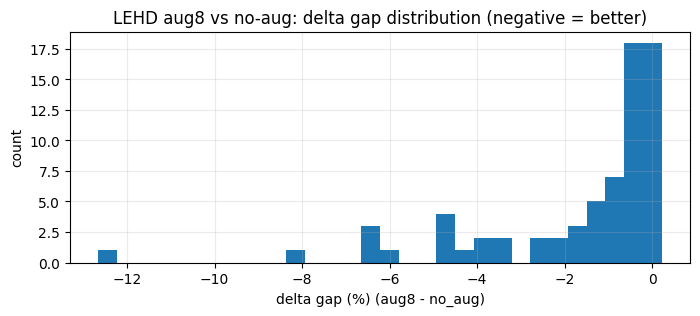

In [26]:
# 找到 lehd 两个 run
lehd_no = None
lehd_aug = None
for k in by_run.keys():
    if k[0] != "lehd":
        continue
    if k[1] == "lehd_greedy_no_aug":
        lehd_no = k
    elif k[1] == "lehd_greedy_aug8":
        lehd_aug = k

print("lehd_no:", lehd_no)
print("lehd_aug:", lehd_aug)

if lehd_no and lehd_aug:
    inst_set = run_to_instances[lehd_no] & run_to_instances[lehd_aug]
    delta_rows = []
    for inst in sorted(inst_set):
        g0 = run_gap[lehd_no].get(inst)
        g1 = run_gap[lehd_aug].get(inst)
        if g0 is None or g1 is None:
            continue
        delta_rows.append({
            "instance": inst,
            "n": meta.get(inst, {}).get("n"),
            "gap_no_aug": g0,
            "gap_aug8": g1,
            "delta(aug8-no)": g1 - g0,
        })

    improved = sum(1 for r in delta_rows if r["delta(aug8-no)"] < 0)
    worsened = sum(1 for r in delta_rows if r["delta(aug8-no)"] > 0)
    same = len(delta_rows) - improved - worsened
    print(f"LEHD: improved={improved}, worsened={worsened}, same={same}, total={len(delta_rows)}")

    delta_rows_sorted = sorted(delta_rows, key=lambda x: x["delta(aug8-no)"])
    display_table(delta_rows_sorted[:20], ["instance", "n", "gap_no_aug", "gap_aug8", "delta(aug8-no)"], max_rows=20, title="提升最大(最负)的 20 个实例")
    display_table(delta_rows_sorted[-20:], ["instance", "n", "gap_no_aug", "gap_aug8", "delta(aug8-no)"], max_rows=20, title="退化最大(最正)的 20 个实例")

    # 画 delta 的直方图
    plt.figure(figsize=(8, 3))
    plt.hist([r["delta(aug8-no)"] for r in delta_rows], bins=30)
    plt.xlabel('delta gap (%) (aug8 - no_aug)')
    plt.ylabel('count')
    plt.title('LEHD aug8 vs no-aug: delta gap distribution (negative = better)')
    plt.grid(True, alpha=0.25)
    plt.show()
else:
    print("⚠️ 没找到完整的 lehd_greedy_no_aug 与 lehd_greedy_aug8 两个 run，跳过该对比。")


## 14. `tsplib3` 的 9 个超大实例（目前常见只在 LEHD 日志里出现）

`EasyNCO/data/datasets/tsplib/tsplib3/` 中的 9 个实例是：

- `d1655`, `d2103`, `fl3795`, `fnl4461`, `pcb3038`, `pr2392`, `u1817`, `u2152`, `u2319`

很多方法的预训练或推理代码在这种规模上：

- 要么非常慢
- 要么显存/内存压力大
- 要么被评测脚本/数据加载逻辑剔除了

这里把这 9 个实例单独列出来，查看当前日志里有哪些方法覆盖，以及 gap 分别是多少。


In [27]:
tsplib3_names = [
    "d1655",
    "d2103",
    "fl3795",
    "fnl4461",
    "pcb3038",
    "pr2392",
    "u1817",
    "u2152",
    "u2319",
]

rows = []
for name in tsplib3_names:
    m = meta.get(name, {})
    rows.append({
        "instance": name,
        "n": m.get("n"),
        "edge_weight_type": m.get("edge_weight_type"),
        "optimal": m.get("optimal"),
        "tsp_path": m.get("tsp_path"),
    })
display_table(rows, ["instance", "n", "edge_weight_type", "optimal", "tsp_path"], max_rows=20, title="tsplib3 9 个实例的元数据")

# 哪些 run 覆盖了这些？
cover_rows = []
for k, insts in run_to_instances.items():
    inter = sorted(set(tsplib3_names) & insts)
    if not inter:
        continue
    cover_rows.append({
        "run": f"{k[0]}/{k[1]}",
        "covered": ", ".join(inter),
    })
display_table(cover_rows, ["run", "covered"], max_rows=50, title="哪些 run 覆盖了 tsplib3 的实例")

# 如果 lehd 的两个 run 都存在，就列出它们在这 9 个实例上的 gap
if lehd_no and lehd_aug:
    detail = []
    for inst in tsplib3_names:
        g0 = run_gap[lehd_no].get(inst)
        g1 = run_gap[lehd_aug].get(inst)
        detail.append({
            "instance": inst,
            "n": meta.get(inst, {}).get("n"),
            "lehd_no_aug_gap": g0,
            "lehd_aug8_gap": g1,
            "delta": (g1 - g0) if (g0 is not None and g1 is not None) else None,
        })
    display_table(detail, ["instance", "n", "lehd_no_aug_gap", "lehd_aug8_gap", "delta"], max_rows=20, title="LEHD 在 tsplib3 上的 gap")



tsplib3 9 个实例的元数据


instance,n,edge_weight_type,optimal,tsp_path
d1655,1655,EUC_2D,62128.0,/mnt/d/Study/3/neural-solver-selection/EasyNCO/data/datasets/tsplib/tsplib3/d1655.tsp
d2103,2103,EUC_2D,80450.0,/mnt/d/Study/3/neural-solver-selection/EasyNCO/data/datasets/tsplib/tsplib3/d2103.tsp
fl3795,3795,EUC_2D,28772.0,/mnt/d/Study/3/neural-solver-selection/EasyNCO/data/datasets/tsplib/tsplib3/fl3795.tsp
fnl4461,4461,EUC_2D,182566.0,/mnt/d/Study/3/neural-solver-selection/EasyNCO/data/datasets/tsplib/tsplib3/fnl4461.tsp
pcb3038,3038,EUC_2D,137694.0,/mnt/d/Study/3/neural-solver-selection/EasyNCO/data/datasets/tsplib/tsplib3/pcb3038.tsp
pr2392,2392,EUC_2D,378032.0,/mnt/d/Study/3/neural-solver-selection/EasyNCO/data/datasets/tsplib/tsplib3/pr2392.tsp
u1817,1817,EUC_2D,57201.0,/mnt/d/Study/3/neural-solver-selection/EasyNCO/data/datasets/tsplib/tsplib3/u1817.tsp
u2152,2152,EUC_2D,64253.0,/mnt/d/Study/3/neural-solver-selection/EasyNCO/data/datasets/tsplib/tsplib3/u2152.tsp
u2319,2319,EUC_2D,234256.0,/mnt/d/Study/3/neural-solver-selection/EasyNCO/data/datasets/tsplib/tsplib3/u2319.tsp



哪些 run 覆盖了 tsplib3 的实例


run,covered
lehd/lehd_greedy_aug8,"d1655, d2103, fl3795, fnl4461, pcb3038, pr2392, u1817, u2152, u2319"
lehd/lehd_greedy_no_aug,"d1655, d2103, fl3795, fnl4461, pcb3038, pr2392, u1817, u2152, u2319"



LEHD 在 tsplib3 上的 gap


instance,n,lehd_no_aug_gap,lehd_aug8_gap,delta
d1655,1655,13.9063,12.7076,-1.1987000000000005
d2103,2103,10.6731,6.2817,-4.3914
fl3795,3795,20.4682,12.2864,-8.181799999999999
fnl4461,4461,17.8006,17.2913,-0.5092999999999996
pcb3038,3038,12.525,11.1959,-1.3291000000000004
pr2392,2392,10.5612,10.781,0.2198000000000011
u1817,1817,10.0971,8.079,-2.0180999999999987
u2152,2152,11.6538,10.042,-1.6118000000000006
u2319,2319,2.3077,2.4007,0.09299999999999997


## 15. 导出（可选）：把长表写成 TSV 方便你做进一步分析

如果你希望后续用 Excel / 其它脚本分析，可以把 `records` 导出为一个 TSV。

- 默认写到：`results/tsplib70_log_analysis/tsplib70_runs_long.tsv`
- 不会覆盖你原始日志文件


In [28]:
out_dir = REPO_ROOT / "results" / "tsplib70_log_analysis"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "tsplib70_runs_long.tsv"

headers = [
    "method",
    "variant",
    "kind",
    "instance",
    "n",
    "edge_weight_type",
    "optimal",
    "score",
    "aug_score",
    "gap",
    "aug_gap",
    "aug_factor",
    "primary_gap",
    "time_sec",
]

with out_path.open("w", encoding="utf-8", newline="") as f:
    w = csv.DictWriter(f, fieldnames=headers, delimiter="\t")
    w.writeheader()
    for r in records:
        w.writerow({h: r.get(h) for h in headers})

print("写出:", out_path)


写出: /mnt/d/Study/3/neural-solver-selection/results/tsplib70_log_analysis/tsplib70_runs_long.tsv
